In [1]:
import os, math, scipy, skbio
import statistics
import numpy as np
import pandas as pd
from skbio.diversity import beta_diversity
from skbio.stats.ordination import pcoa
import seaborn as sns
import matplotlib as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
import statsmodels
import warnings
import scipy.stats as sts
warnings.filterwarnings("ignore")
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
metadata = pd.read_table('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_metadata.tsv')

In [3]:
abundances = pd.read_table('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_profiles.tsv',sep = '\t', index_col=0)
abundances

,MMRS62666492ST-27-0-0,MMRS51737257ST-27-0-0,MMRS38861560ST-27-0-0,MMRS95674036ST-27-0-0,MMRS67096717ST-27-0-0,MMRS84085284ST-27-0-0,MMRS51307502ST-27-0-0,MMRS17963147ST-27-0-0,MMRS39582183ST-27-0-0,MMRS35808664ST-27-0-0,...,SID15785561_SF07,SID19401504_SF05,SID20269046_SF08,SID50492523_SF07,SID10502288_SF08,SID72242320_SF07,SID30920067_SF07,SID11486372_SF08,SID16913125_SF05,SID16853657_SF05
k__Bacteria,99.93463,99.18388,100.00000,100.00000,100.00000,100.00000,97.99128,99.92570,93.18519,99.99433,...,100.00000,100.00000,99.20735,100.00000,99.62772,99.57517,99.92819,99.93030,99.53060,100.00000
k__Archaea,0.06537,0.81612,0.00000,0.00000,0.00000,0.00000,2.00872,0.07430,6.81481,0.00567,...,0.00000,0.00000,0.79265,0.00000,0.37228,0.42483,0.07181,0.06970,0.46940,0.00000
k__Bacteria|p__Firmicutes,69.66820,58.11043,69.86201,28.13507,54.76472,48.93404,81.31657,53.89673,70.39620,38.26343,...,62.99205,57.98725,77.37153,56.84940,62.01985,70.64182,57.19654,64.96287,72.69495,56.00511
k__Bacteria|p__Bacteroidetes,28.66924,37.02095,28.10208,66.97080,20.40542,48.32282,10.73218,42.41865,19.37239,51.40790,...,35.22573,38.97574,16.54528,35.27852,27.46251,21.14656,39.11211,20.96019,17.53030,37.48840
k__Bacteria|p__Proteobacteria,0.67858,1.44754,0.66079,2.82776,0.67835,0.02112,3.02764,2.76147,1.31107,9.69329,...,0.49921,0.86482,0.72299,3.39898,3.28930,2.96303,1.12058,11.84127,2.04371,0.62305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Bacteroidales_unclassified|g__GGB27883|s__GGB27883_SGB40317,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Bacteroidales_unclassified|g__GGB27883|s__GGB27883_SGB40317|t__SGB40317,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
k__Bacteria|p__Bacteroidetes|c__CFGB570|o__OFGB570|f__FGB570|g__GGB1201,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
k__Bacteria|p__Bacteroidetes|c__CFGB570|o__OFGB570|f__FGB570|g__GGB1201|s__GGB1201_SGB1566,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000


In [4]:
keep = list()
for x in abundances.index.tolist():
    keep.append('t__' in x)
sgb_abundances = abundances.loc[keep]

In [5]:
set(metadata['study_condition'].tolist())

{'control', nan}

In [6]:
adults_metadata = metadata[metadata['age'] != pd.NA]
adults_metadata = adults_metadata[adults_metadata['age'] != np.nan]
adults_metadata = adults_metadata[adults_metadata['age'].notna()]
adults_metadata = adults_metadata[adults_metadata['age'] != '1.083.333.333']
adults_metadata['age'] = adults_metadata['age'].astype(float)
adults_metadata = adults_metadata[adults_metadata['age'] > 16]
m = pd.DataFrame(metadata)
china = m[m['study_name'] == 'CM_china']
china = china[china['age'].isna()]
adults_metadata = pd.concat([adults_metadata,china])
m = pd.DataFrame(metadata)
ancient = m[m['non_westernized'] == 'ancient']
ancient = ancient[ancient['study_name'] != 'RifkinRF_2020']
adults_metadata = pd.concat([adults_metadata,ancient])
adults_metadata.index = adults_metadata['sample_id']
adults_metadata

,study_name,sample_id,subject_id,body_site,antibiotics_current_use,study_condition,disease,age,age_category,gender,...,non_westernized,sequencing_platform,PMID,number_reads,number_bases,minimum_read_length,median_read_length,NCBI_accession,curator,DNA_extraction_kit
sample_id,,,,,,,,,,,,,,,,,,,,,
O2_UC49_0,NielsenHB_2014,O2_UC49_0,O2_UC49,stool,NaN,control,healthy,22.0,adult,female,...,no,IlluminaHiSeq,24997787.0,60584637.0,4.099972e+09,30.0,70.0,ERR210493;ERR210492;ERR209641;ERR209640,Paolo_Manghi,NaN
O2_UC49_2,NielsenHB_2014,O2_UC49_2,O2_UC49,stool,NaN,control,healthy,22.0,adult,female,...,no,IlluminaHiSeq,24997787.0,56508214.0,3.775477e+09,30.0,70.0,ERR210495;ERR210494;ERR209643;ERR209642,Paolo_Manghi,NaN
O2_UC50_0,NielsenHB_2014,O2_UC50_0,O2_UC50,stool,NaN,control,healthy,24.0,adult,male,...,no,IlluminaHiSeq,24997787.0,65105855.0,4.392995e+09,30.0,71.0,ERR210497;ERR210496;ERR209645;ERR209644,Paolo_Manghi,NaN
O2_UC50_2,NielsenHB_2014,O2_UC50_2,O2_UC50,stool,NaN,control,healthy,24.0,adult,male,...,no,IlluminaHiSeq,24997787.0,53260679.0,3.596382e+09,30.0,70.0,ERR210500;ERR209648,Paolo_Manghi,NaN
O2_UC51_0,NielsenHB_2014,O2_UC51_0,O2_UC51,stool,NaN,control,healthy,32.0,adult,female,...,no,IlluminaHiSeq,24997787.0,57486896.0,3.923766e+09,30.0,72.0,ERR210502;ERR210501;ERR209650;ERR209649,Paolo_Manghi,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SAMEA6415059,BorryM_2020,SAMEA6415059,SAMEA6415059,stool,NaN,control,healthy,NaN,NaN,NaN,...,ancient,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ERR3761407,BorryM_2020,ERR3761407,ERR3761407,stool,NaN,control,healthy,NaN,NaN,NaN,...,ancient,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ERR3761411,BorryM_2020,ERR3761411,ERR3761411,stool,NaN,control,healthy,NaN,NaN,NaN,...,ancient,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
adults_metadata[adults_metadata['non_westernized'] != 'ancient']

,study_name,sample_id,subject_id,body_site,antibiotics_current_use,study_condition,disease,age,age_category,gender,...,non_westernized,sequencing_platform,PMID,number_reads,number_bases,minimum_read_length,median_read_length,NCBI_accession,curator,DNA_extraction_kit
sample_id,,,,,,,,,,,,,,,,,,,,,
O2_UC49_0,NielsenHB_2014,O2_UC49_0,O2_UC49,stool,NaN,control,healthy,22.0,adult,female,...,no,IlluminaHiSeq,24997787.0,60584637.0,4.099972e+09,30.0,70.0,ERR210493;ERR210492;ERR209641;ERR209640,Paolo_Manghi,NaN
O2_UC49_2,NielsenHB_2014,O2_UC49_2,O2_UC49,stool,NaN,control,healthy,22.0,adult,female,...,no,IlluminaHiSeq,24997787.0,56508214.0,3.775477e+09,30.0,70.0,ERR210495;ERR210494;ERR209643;ERR209642,Paolo_Manghi,NaN
O2_UC50_0,NielsenHB_2014,O2_UC50_0,O2_UC50,stool,NaN,control,healthy,24.0,adult,male,...,no,IlluminaHiSeq,24997787.0,65105855.0,4.392995e+09,30.0,71.0,ERR210497;ERR210496;ERR209645;ERR209644,Paolo_Manghi,NaN
O2_UC50_2,NielsenHB_2014,O2_UC50_2,O2_UC50,stool,NaN,control,healthy,24.0,adult,male,...,no,IlluminaHiSeq,24997787.0,53260679.0,3.596382e+09,30.0,70.0,ERR210500;ERR209648,Paolo_Manghi,NaN
O2_UC51_0,NielsenHB_2014,O2_UC51_0,O2_UC51,stool,NaN,control,healthy,32.0,adult,female,...,no,IlluminaHiSeq,24997787.0,57486896.0,3.923766e+09,30.0,72.0,ERR210502;ERR210501;ERR209650;ERR209649,Paolo_Manghi,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CHN_26G3,CM_china,CHN_26G3,CHN_26G3,stool,NaN,control,healthy,NaN,NaN,female,...,yes,IlluminaNovaSeq,1.0,452852232.0,6.797313e+10,75.0,151.0,NaN,Mireia_Valles-Colomer,NaN
CHN_2D3,CM_china,CHN_2D3,CHN_2D3,stool,NaN,control,healthy,NaN,NaN,female,...,yes,IlluminaNovaSeq,1.0,82005669.0,1.227308e+10,75.0,151.0,NaN,Mireia_Valles-Colomer,NaN
CHN_4E3,CM_china,CHN_4E3,CHN_4E3,stool,NaN,control,healthy,NaN,NaN,female,...,yes,IlluminaNovaSeq,1.0,40651703.0,6.096303e+09,75.0,151.0,NaN,Mireia_Valles-Colomer,NaN


In [8]:
sgb_abundances.index = [x.split('|')[-2][3:].replace('_',' ') + ' (' + x.split('|')[-1][3:] +')' for x in sgb_abundances.index.tolist()]

In [9]:
sgb_abundances

,MMRS62666492ST-27-0-0,MMRS51737257ST-27-0-0,MMRS38861560ST-27-0-0,MMRS95674036ST-27-0-0,MMRS67096717ST-27-0-0,MMRS84085284ST-27-0-0,MMRS51307502ST-27-0-0,MMRS17963147ST-27-0-0,MMRS39582183ST-27-0-0,MMRS35808664ST-27-0-0,...,SID15785561_SF07,SID19401504_SF05,SID20269046_SF08,SID50492523_SF07,SID10502288_SF08,SID72242320_SF07,SID30920067_SF07,SID11486372_SF08,SID16913125_SF05,SID16853657_SF05
Prevotella copri clade A (SGB1626),11.54777,0.00000,0.00561,0.0,0.00000,9.73808,0.00234,0.0008,5.30270,28.78837,...,0.0,0.0,1.29064,0.00000,0.00000,0.00000,24.37621,0.0,0.00000,0.0
Ruminococcus sp NSJ 71 (SGB4290),6.73408,0.67540,3.45553,0.0,0.00133,0.00000,0.15589,0.0000,0.00000,0.38613,...,0.0,0.0,2.76623,0.00000,0.00000,0.00000,0.00000,0.0,4.52322,0.0
Coprococcus eutactus (SGB5117),5.34157,0.00041,1.53598,0.0,0.00000,0.00000,0.00000,0.0000,0.75849,0.00000,...,0.0,0.0,0.61609,0.00000,0.00000,1.05172,0.94246,0.0,0.00000,0.0
GGB3226 SGB4260 (SGB4260),3.17368,0.00000,0.00000,0.0,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,...,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0
Ruminococcaceae unclassified SGB15234 (SGB15234),2.98767,0.00000,0.70183,0.0,0.00000,0.00000,0.92188,0.0000,0.09317,0.00000,...,0.0,0.0,0.16389,0.22321,2.28257,0.88860,0.00000,0.0,2.07058,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GGB28250 SGB40793 (SGB40793),0.00000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,...,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0
GGB27924 SGB40362 (SGB40362),0.00000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,...,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0
Propionibacteriaceae bacterium NML 150081 (SGB15922),0.00000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,...,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0
GGB27883 SGB40317 (SGB40317),0.00000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,...,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0


In [10]:
adults_abundances = sgb_abundances[adults_metadata['sample_id']]
adults_abundances

,O2_UC49_0,O2_UC49_2,O2_UC50_0,O2_UC50_2,O2_UC51_0,O2_UC51_2,O2_UC52_0,O2_UC53_0,O2_UC53_2,O2_UC54_0,...,AZ110A,Zape3,ERR3761413,ERR3761410,ERR3761412,SAMEA6415059,ERR3761407,ERR3761411,Zape5,Zape28
Prevotella copri clade A (SGB1626),0.0,0.00000,0.99226,0.00000,0.00000,0.00000,2.95526,0.0,0.00000,0.0,...,6.44921,3.85131,11.4166,16.0544,0.92784,0.63677,0.0,0.89185,0.78414,2.19731
Ruminococcus sp NSJ 71 (SGB4290),0.0,0.00000,7.81511,5.32192,0.00000,0.00000,7.74245,0.0,0.00000,0.0,...,0.04583,0.00615,0.0000,0.0000,0.01291,0.74065,0.0,0.00000,0.00000,0.00000
Coprococcus eutactus (SGB5117),0.0,0.00000,0.05737,0.00000,4.03200,2.26458,0.16282,0.0,0.00000,0.0,...,0.28039,0.07902,0.0000,0.0000,0.06048,0.00889,0.0,0.00000,0.00178,0.00000
GGB3226 SGB4260 (SGB4260),0.0,0.00000,0.00000,0.00000,0.72760,1.39484,0.00000,0.0,0.00000,0.0,...,0.00000,0.02358,0.0000,0.0000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000
Ruminococcaceae unclassified SGB15234 (SGB15234),0.0,0.48968,0.14505,0.00000,0.04497,0.06637,0.18059,0.0,0.01218,0.0,...,0.00171,0.41043,0.0000,0.0000,0.00000,0.09056,0.0,0.00000,2.12914,0.14191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GGB28250 SGB40793 (SGB40793),0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.0000,0.0000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000
GGB27924 SGB40362 (SGB40362),0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.0000,0.0000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000
Propionibacteriaceae bacterium NML 150081 (SGB15922),0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.0000,0.0000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000
GGB27883 SGB40317 (SGB40317),0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.0000,0.0000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000


In [11]:
adults_abundances = adults_abundances.drop(adults_abundances.loc[adults_abundances.sum(axis=1) == 0].index.tolist())
adults_abundances = adults_abundances.transpose()
adults_abundances = adults_abundances.drop(adults_abundances.loc[adults_abundances.sum(axis=1) == 0].index.tolist())
adults_abundances = adults_abundances.transpose()
adults_abundances

,O2_UC49_0,O2_UC49_2,O2_UC50_0,O2_UC50_2,O2_UC51_0,O2_UC51_2,O2_UC52_0,O2_UC53_0,O2_UC53_2,O2_UC54_0,...,AZ110A,Zape3,ERR3761413,ERR3761410,ERR3761412,SAMEA6415059,ERR3761407,ERR3761411,Zape5,Zape28
Prevotella copri clade A (SGB1626),0.0,0.00000,0.99226,0.00000,0.00000,0.00000,2.95526,0.0,0.00000,0.0,...,6.44921,3.85131,11.4166,16.0544,0.92784,0.63677,0.0,0.89185,0.78414,2.19731
Ruminococcus sp NSJ 71 (SGB4290),0.0,0.00000,7.81511,5.32192,0.00000,0.00000,7.74245,0.0,0.00000,0.0,...,0.04583,0.00615,0.0000,0.0000,0.01291,0.74065,0.0,0.00000,0.00000,0.00000
Coprococcus eutactus (SGB5117),0.0,0.00000,0.05737,0.00000,4.03200,2.26458,0.16282,0.0,0.00000,0.0,...,0.28039,0.07902,0.0000,0.0000,0.06048,0.00889,0.0,0.00000,0.00178,0.00000
GGB3226 SGB4260 (SGB4260),0.0,0.00000,0.00000,0.00000,0.72760,1.39484,0.00000,0.0,0.00000,0.0,...,0.00000,0.02358,0.0000,0.0000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000
Ruminococcaceae unclassified SGB15234 (SGB15234),0.0,0.48968,0.14505,0.00000,0.04497,0.06637,0.18059,0.0,0.01218,0.0,...,0.00171,0.41043,0.0000,0.0000,0.00000,0.09056,0.0,0.00000,2.12914,0.14191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Arcobacter trophiarum (SGB28493),0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.0000,0.0000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000
Aquamicrobium lusatiense (SGB89540),0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.0000,0.0000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000
Proteiniborus ethanoligenes (SGB8530),0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.0000,0.0000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000
Propioniciclava sp MC1595 (SGB87720),0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.0000,0.0000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000


In [12]:
filtered_adults_metadata = adults_metadata[['study_name', 'age', 'gender', 'non_westernized', 'number_reads']]
filtered_adults_metadata

,study_name,age,gender,non_westernized,number_reads
sample_id,,,,,
O2_UC49_0,NielsenHB_2014,22.0,female,no,60584637.0
O2_UC49_2,NielsenHB_2014,22.0,female,no,56508214.0
O2_UC50_0,NielsenHB_2014,24.0,male,no,65105855.0
O2_UC50_2,NielsenHB_2014,24.0,male,no,53260679.0
O2_UC51_0,NielsenHB_2014,32.0,female,no,57486896.0
...,...,...,...,...,...
SAMEA6415059,BorryM_2020,NaN,NaN,ancient,NaN
ERR3761407,BorryM_2020,NaN,NaN,ancient,NaN
ERR3761411,BorryM_2020,NaN,NaN,ancient,NaN


In [13]:
filtered_adults_metadata = filtered_adults_metadata[filtered_adults_metadata['age'] != pd.NA]
filtered_adults_metadata = filtered_adults_metadata[filtered_adults_metadata['age'] != np.nan]
filtered_adults_metadata = filtered_adults_metadata[filtered_adults_metadata['age'].notna()]
filtered_adults_metadata = filtered_adults_metadata[filtered_adults_metadata['gender'] != pd.NA]
filtered_adults_metadata = filtered_adults_metadata[filtered_adults_metadata['gender'] != np.nan]
filtered_adults_metadata = filtered_adults_metadata[filtered_adults_metadata['gender'].notna()]
filtered_adults_metadata = filtered_adults_metadata[filtered_adults_metadata['number_reads'] != pd.NA]
filtered_adults_metadata = filtered_adults_metadata[filtered_adults_metadata['number_reads'] != np.nan]
filtered_adults_metadata = filtered_adults_metadata[filtered_adults_metadata['number_reads'].notna()]
filtered_adults_metadata

,study_name,age,gender,non_westernized,number_reads
sample_id,,,,,
O2_UC49_0,NielsenHB_2014,22.0,female,no,60584637.0
O2_UC49_2,NielsenHB_2014,22.0,female,no,56508214.0
O2_UC50_0,NielsenHB_2014,24.0,male,no,65105855.0
O2_UC50_2,NielsenHB_2014,24.0,male,no,53260679.0
O2_UC51_0,NielsenHB_2014,32.0,female,no,57486896.0
...,...,...,...,...,...
C16-20627-TZ,CM_tanzania,20.0,male,yes,38426298.0
C16-20645-TZ,CM_tanzania,34.0,female,yes,66130906.0
C16-20646-TZ,CM_tanzania,40.0,male,yes,66850184.0


In [14]:
filtered_adults_abundances = sgb_abundances[filtered_adults_metadata.index]
filtered_adults_abundances = filtered_adults_abundances.drop(filtered_adults_abundances.loc[filtered_adults_abundances.sum(axis=1) == 0].index.tolist())
filtered_adults_abundances = filtered_adults_abundances.transpose()
filtered_adults_abundances = filtered_adults_abundances.drop(filtered_adults_abundances.loc[filtered_adults_abundances.sum(axis=1) == 0].index.tolist())
filtered_adults_abundances = filtered_adults_abundances.transpose()
filtered_adults_abundances

,O2_UC49_0,O2_UC49_2,O2_UC50_0,O2_UC50_2,O2_UC51_0,O2_UC51_2,O2_UC52_0,O2_UC53_0,O2_UC53_2,O2_UC54_0,...,C16-20615-TZ,C16-20616-TZ,C16-20617-TZ,C16-20625-TZ,C16-20626-TZ,C16-20627-TZ,C16-20645-TZ,C16-20646-TZ,C16-20647-TZ,C16-20664-TZ
Prevotella copri clade A (SGB1626),0.0,0.00000,0.99226,0.00000,0.00000,0.00000,2.95526,0.0,0.00000,0.0,...,4.67726,5.30976,20.47193,12.11931,5.17480,8.29545,7.22606,6.61441,0.68483,0.49648
Ruminococcus sp NSJ 71 (SGB4290),0.0,0.00000,7.81511,5.32192,0.00000,0.00000,7.74245,0.0,0.00000,0.0,...,0.23187,0.21361,0.00000,0.05948,0.00000,2.73756,0.04019,0.01647,0.00000,0.00000
Coprococcus eutactus (SGB5117),0.0,0.00000,0.05737,0.00000,4.03200,2.26458,0.16282,0.0,0.00000,0.0,...,0.00000,0.00000,0.19342,1.06580,0.07770,0.00000,0.00293,0.03258,0.21350,1.87686
GGB3226 SGB4260 (SGB4260),0.0,0.00000,0.00000,0.00000,0.72760,1.39484,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.01816,0.00000,0.07773,0.00000
Ruminococcaceae unclassified SGB15234 (SGB15234),0.0,0.48968,0.14505,0.00000,0.04497,0.06637,0.18059,0.0,0.01218,0.0,...,0.11756,0.14315,0.02202,0.00128,0.01109,0.03210,0.08475,0.06938,0.01028,0.04632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Arcobacter trophiarum (SGB28493),0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
Aquamicrobium lusatiense (SGB89540),0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
Proteiniborus ethanoligenes (SGB8530),0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
Propioniciclava sp MC1595 (SGB87720),0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000


In [15]:
filtered_adults_abundances.index = [x.replace(' ','_').replace('(', '__').replace(')','') for x in filtered_adults_abundances.index.tolist()]
filtered_adults_abundances

,O2_UC49_0,O2_UC49_2,O2_UC50_0,O2_UC50_2,O2_UC51_0,O2_UC51_2,O2_UC52_0,O2_UC53_0,O2_UC53_2,O2_UC54_0,...,C16-20615-TZ,C16-20616-TZ,C16-20617-TZ,C16-20625-TZ,C16-20626-TZ,C16-20627-TZ,C16-20645-TZ,C16-20646-TZ,C16-20647-TZ,C16-20664-TZ
Prevotella_copri_clade_A___SGB1626,0.0,0.00000,0.99226,0.00000,0.00000,0.00000,2.95526,0.0,0.00000,0.0,...,4.67726,5.30976,20.47193,12.11931,5.17480,8.29545,7.22606,6.61441,0.68483,0.49648
Ruminococcus_sp_NSJ_71___SGB4290,0.0,0.00000,7.81511,5.32192,0.00000,0.00000,7.74245,0.0,0.00000,0.0,...,0.23187,0.21361,0.00000,0.05948,0.00000,2.73756,0.04019,0.01647,0.00000,0.00000
Coprococcus_eutactus___SGB5117,0.0,0.00000,0.05737,0.00000,4.03200,2.26458,0.16282,0.0,0.00000,0.0,...,0.00000,0.00000,0.19342,1.06580,0.07770,0.00000,0.00293,0.03258,0.21350,1.87686
GGB3226_SGB4260___SGB4260,0.0,0.00000,0.00000,0.00000,0.72760,1.39484,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.01816,0.00000,0.07773,0.00000
Ruminococcaceae_unclassified_SGB15234___SGB15234,0.0,0.48968,0.14505,0.00000,0.04497,0.06637,0.18059,0.0,0.01218,0.0,...,0.11756,0.14315,0.02202,0.00128,0.01109,0.03210,0.08475,0.06938,0.01028,0.04632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Arcobacter_trophiarum___SGB28493,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
Aquamicrobium_lusatiense___SGB89540,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
Proteiniborus_ethanoligenes___SGB8530,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
Propioniciclava_sp_MC1595___SGB87720,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000


In [16]:
filtered_adults_metadata = filtered_adults_metadata.loc[filtered_adults_abundances.columns]
filtered_adults_metadata = filtered_adults_metadata[filtered_adults_metadata['study_name'] != 'CM_china']
filtered_adults_metadata = filtered_adults_metadata[filtered_adults_metadata['study_name'] != 'HanniganGD_2017']
filtered_adults_metadata = filtered_adults_metadata.transpose()
filtered_adults_metadata

,O2_UC49_0,O2_UC49_2,O2_UC50_0,O2_UC50_2,O2_UC51_0,O2_UC51_2,O2_UC52_0,O2_UC53_0,O2_UC53_2,O2_UC54_0,...,C16-20615-TZ,C16-20616-TZ,C16-20617-TZ,C16-20625-TZ,C16-20626-TZ,C16-20627-TZ,C16-20645-TZ,C16-20646-TZ,C16-20647-TZ,C16-20664-TZ
study_name,NielsenHB_2014,NielsenHB_2014,NielsenHB_2014,NielsenHB_2014,NielsenHB_2014,NielsenHB_2014,NielsenHB_2014,NielsenHB_2014,NielsenHB_2014,NielsenHB_2014,...,CM_tanzania2,CM_tanzania2,CM_tanzania2,CM_tanzania,CM_tanzania,CM_tanzania,CM_tanzania,CM_tanzania,CM_tanzania,CM_tanzania2
age,22.0,22.0,24.0,24.0,32.0,32.0,32.0,21.0,21.0,20.0,...,27.0,31.0,24.0,20.0,25.0,20.0,34.0,40.0,18.0,48.0
gender,female,female,male,male,female,female,female,male,male,male,...,female,male,female,female,male,male,female,male,female,male
non_westernized,no,no,no,no,no,no,no,no,no,no,...,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
number_reads,60584637.0,56508214.0,65105855.0,53260679.0,57486896.0,117575131.0,60333297.0,50010311.0,58698482.0,54368659.0,...,28965115.0,20811913.0,29903092.0,49299720.0,36316653.0,38426298.0,66130906.0,66850184.0,62136875.0,44148555.0


In [17]:
filtered_adults_abundances = filtered_adults_abundances[filtered_adults_metadata.columns]

In [18]:
filtered_adults_metadata

,O2_UC49_0,O2_UC49_2,O2_UC50_0,O2_UC50_2,O2_UC51_0,O2_UC51_2,O2_UC52_0,O2_UC53_0,O2_UC53_2,O2_UC54_0,...,C16-20615-TZ,C16-20616-TZ,C16-20617-TZ,C16-20625-TZ,C16-20626-TZ,C16-20627-TZ,C16-20645-TZ,C16-20646-TZ,C16-20647-TZ,C16-20664-TZ
study_name,NielsenHB_2014,NielsenHB_2014,NielsenHB_2014,NielsenHB_2014,NielsenHB_2014,NielsenHB_2014,NielsenHB_2014,NielsenHB_2014,NielsenHB_2014,NielsenHB_2014,...,CM_tanzania2,CM_tanzania2,CM_tanzania2,CM_tanzania,CM_tanzania,CM_tanzania,CM_tanzania,CM_tanzania,CM_tanzania,CM_tanzania2
age,22.0,22.0,24.0,24.0,32.0,32.0,32.0,21.0,21.0,20.0,...,27.0,31.0,24.0,20.0,25.0,20.0,34.0,40.0,18.0,48.0
gender,female,female,male,male,female,female,female,male,male,male,...,female,male,female,female,male,male,female,male,female,male
non_westernized,no,no,no,no,no,no,no,no,no,no,...,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
number_reads,60584637.0,56508214.0,65105855.0,53260679.0,57486896.0,117575131.0,60333297.0,50010311.0,58698482.0,54368659.0,...,28965115.0,20811913.0,29903092.0,49299720.0,36316653.0,38426298.0,66130906.0,66850184.0,62136875.0,44148555.0


In [19]:
filtered_adults_abundances

,O2_UC49_0,O2_UC49_2,O2_UC50_0,O2_UC50_2,O2_UC51_0,O2_UC51_2,O2_UC52_0,O2_UC53_0,O2_UC53_2,O2_UC54_0,...,C16-20615-TZ,C16-20616-TZ,C16-20617-TZ,C16-20625-TZ,C16-20626-TZ,C16-20627-TZ,C16-20645-TZ,C16-20646-TZ,C16-20647-TZ,C16-20664-TZ
Prevotella_copri_clade_A___SGB1626,0.0,0.00000,0.99226,0.00000,0.00000,0.00000,2.95526,0.0,0.00000,0.0,...,4.67726,5.30976,20.47193,12.11931,5.17480,8.29545,7.22606,6.61441,0.68483,0.49648
Ruminococcus_sp_NSJ_71___SGB4290,0.0,0.00000,7.81511,5.32192,0.00000,0.00000,7.74245,0.0,0.00000,0.0,...,0.23187,0.21361,0.00000,0.05948,0.00000,2.73756,0.04019,0.01647,0.00000,0.00000
Coprococcus_eutactus___SGB5117,0.0,0.00000,0.05737,0.00000,4.03200,2.26458,0.16282,0.0,0.00000,0.0,...,0.00000,0.00000,0.19342,1.06580,0.07770,0.00000,0.00293,0.03258,0.21350,1.87686
GGB3226_SGB4260___SGB4260,0.0,0.00000,0.00000,0.00000,0.72760,1.39484,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.01816,0.00000,0.07773,0.00000
Ruminococcaceae_unclassified_SGB15234___SGB15234,0.0,0.48968,0.14505,0.00000,0.04497,0.06637,0.18059,0.0,0.01218,0.0,...,0.11756,0.14315,0.02202,0.00128,0.01109,0.03210,0.08475,0.06938,0.01028,0.04632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Arcobacter_trophiarum___SGB28493,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
Aquamicrobium_lusatiense___SGB89540,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
Proteiniborus_ethanoligenes___SGB8530,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
Propioniciclava_sp_MC1595___SGB87720,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000


## Test Aitor

In [31]:
not_to_use = ['Prevotella copri clade A (SGB1626)', 'Prevotella SGB1653 (SGB1653)',
       'Prevotella hominis (SGB1617_group)', 'GGB1617 SGB2214 (SGB2214)',
       'Prevotella copri clade B (SGB1613)',
       'Prevotella copri clade C (SGB1644)', 'GGB1680 SGB2312 (SGB2312)',
       'Prevotella SGB1680 (SGB1680)',
       'Prevotella stercorea (SGB1679)',
       'Prevotella copri clade D (SGB1636_group)',
       'Prevotella sp P4 51 (SGB1666)',
       'Prevotella sp 885 (SGB1677)',
       'Prevotella sp Marseille P4119 (SGB1676)']
not_to_use = [x.replace(' (','___').replace(' ','_')[:-1] for x in not_to_use]
not_to_use

['Prevotella_copri_clade_A___SGB1626',
 'Prevotella_SGB1653___SGB1653',
 'Prevotella_hominis___SGB1617_group',
 'GGB1617_SGB2214___SGB2214',
 'Prevotella_copri_clade_B___SGB1613',
 'Prevotella_copri_clade_C___SGB1644',
 'GGB1680_SGB2312___SGB2312',
 'Prevotella_SGB1680___SGB1680',
 'Prevotella_stercorea___SGB1679',
 'Prevotella_copri_clade_D___SGB1636_group',
 'Prevotella_sp_P4_51___SGB1666',
 'Prevotella_sp_885___SGB1677',
 'Prevotella_sp_Marseille_P4119___SGB1676']

In [60]:
tmp = filtered_adults_abundances.copy() #.loc[[x for x in filtered_adults_abundances.index if x not in not_to_use]]
tmp = 100 * tmp / tmp.sum()
tmp

,O2_UC49_0,O2_UC49_2,O2_UC50_0,O2_UC50_2,O2_UC51_0,O2_UC51_2,O2_UC52_0,O2_UC53_0,O2_UC53_2,O2_UC54_0,...,C16-20615-TZ,C16-20616-TZ,C16-20617-TZ,C16-20625-TZ,C16-20626-TZ,C16-20627-TZ,C16-20645-TZ,C16-20646-TZ,C16-20647-TZ,C16-20664-TZ
Prevotella_copri_clade_A___SGB1626,0.0,0.00000,0.99226,0.000000,0.00000,0.000000,2.955258,0.0,0.00000,0.0,...,4.677263,5.309757,20.471932,12.119318,5.174801,8.295455,7.226065,6.614416,0.68483,0.496480
Ruminococcus_sp_NSJ_71___SGB4290,0.0,0.00000,7.81511,5.321918,0.00000,0.000000,7.742445,0.0,0.00000,0.0,...,0.231870,0.213610,0.000000,0.059480,0.000000,2.737562,0.040190,0.016470,0.00000,0.000000
Coprococcus_eutactus___SGB5117,0.0,0.00000,0.05737,0.000000,4.03200,2.264578,0.162820,0.0,0.00000,0.0,...,0.000000,0.000000,0.193420,1.065801,0.077700,0.000000,0.002930,0.032580,0.21350,1.876859
GGB3226_SGB4260___SGB4260,0.0,0.00000,0.00000,0.000000,0.72760,1.394839,0.000000,0.0,0.00000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.018160,0.000000,0.07773,0.000000
Ruminococcaceae_unclassified_SGB15234___SGB15234,0.0,0.48968,0.14505,0.000000,0.04497,0.066370,0.180590,0.0,0.01218,0.0,...,0.117560,0.143150,0.022020,0.001280,0.011090,0.032100,0.084750,0.069380,0.01028,0.046320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Arcobacter_trophiarum___SGB28493,0.0,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.0,0.00000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
Aquamicrobium_lusatiense___SGB89540,0.0,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.0,0.00000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
Proteiniborus_ethanoligenes___SGB8530,0.0,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.0,0.00000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
Propioniciclava_sp_MC1595___SGB87720,0.0,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.0,0.00000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000


In [35]:
import skbio

In [76]:
adults_prevalences = tmp.T.copy()
adults_prevalences[adults_prevalences > 0] = 1
sgb_richness = adults_prevalences.sum(axis=1)
sgb_richness = pd.DataFrame(sgb_richness)
sgb_richness.columns = ['richness']
sgb_richness['non_westernized'] = adults_metadata.loc[sgb_richness.index,'non_westernized']
sgb_formetrics = tmp.T.copy()
for i in sgb_formetrics.index:
    ab_list = [value for value in sgb_formetrics.loc[i].tolist()]  
    sgb_richness.loc[i, 'shannon'] = skbio.diversity.alpha.shannon(ab_list)
    sgb_richness.loc[i, 'simpson'] = skbio.diversity.alpha.simpson(ab_list)
nr = metadata['number_reads']
nr.index = metadata['sample_id']
sgb_richness['number_reads'] = nr[sgb_richness.index].values
dataset = metadata['study_name']
dataset.index = metadata['sample_id']
sgb_richness['dataset'] = dataset[sgb_richness.index].values
sgb_richness = sgb_richness[sgb_richness['non_westernized'] != 'ancient']
sgb_richness['Prevotella'] = adults_prevalences[not_to_use].T.sum() > 0
sgb_richness

,richness,non_westernized,shannon,simpson,number_reads,dataset,Prevotella
O2_UC49_0,189.0,no,4.998462,0.945377,60584637.0,NielsenHB_2014,True
O2_UC49_2,319.0,no,5.903226,0.967186,56508214.0,NielsenHB_2014,True
O2_UC50_0,461.0,no,6.534548,0.971884,65105855.0,NielsenHB_2014,True
O2_UC50_2,302.0,no,5.849816,0.964972,53260679.0,NielsenHB_2014,False
O2_UC51_0,343.0,no,6.041293,0.968500,57486896.0,NielsenHB_2014,True
...,...,...,...,...,...,...,...
C16-20627-TZ,326.0,yes,5.881988,0.961805,38426298.0,CM_tanzania,True
C16-20645-TZ,530.0,yes,6.636521,0.978569,66130906.0,CM_tanzania,True
C16-20646-TZ,452.0,yes,5.658569,0.957095,66850184.0,CM_tanzania,True
C16-20647-TZ,526.0,yes,6.057918,0.948052,62136875.0,CM_tanzania,True


In [84]:
sgb_richness.groupby(['non_westernized', 'Prevotella'])['shannon'].median()

non_westernized  Prevotella
no               False         5.612956
                 True          5.634785
yes              False         4.381419
                 True          5.444707
Name: shannon, dtype: float64

<Axes: xlabel='non_westernized', ylabel='shannon'>

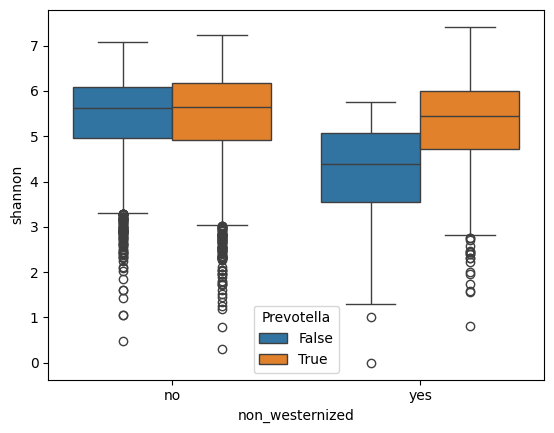

In [77]:
sns.boxplot(data = sgb_richness, x = 'non_westernized', y='shannon', hue='Prevotella')

In [102]:
metadata['study_name']

sample_id
O2_UC49_0       NielsenHB_2014
O2_UC49_2       NielsenHB_2014
O2_UC50_0       NielsenHB_2014
O2_UC50_2       NielsenHB_2014
O2_UC51_0       NielsenHB_2014
                     ...      
SAMEA6415059       BorryM_2020
ERR3761407         BorryM_2020
ERR3761411         BorryM_2020
Zape5             HaganRW_2019
Zape28            HaganRW_2019
Name: study_name, Length: 12870, dtype: object

In [92]:
sgb_richness[(sgb_richness['non_westernized'] == 'yes') & (sgb_richness['Prevotella'] == False)].groupby('dataset')['shannon' ].count()

dataset
CM_argentina           3
CM_ghana               1
CM_ghana2              1
CM_guinea              7
CM_guinea2            12
CM_madagascar          2
CM_tanzania            1
CM_tanzania2           5
CM_tanzania_TB_DAR    38
PehrssonE_2016        12
RubelMA_2020          10
Name: shannon, dtype: int64

<Axes: xlabel='Prevotella', ylabel='shannon'>

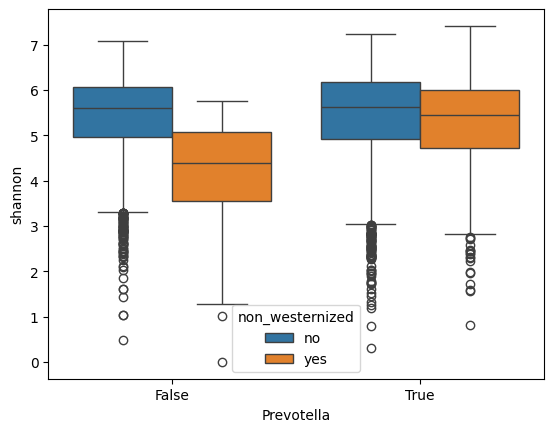

In [78]:
sns.boxplot(data = sgb_richness, hue = 'non_westernized', y='shannon', x='Prevotella')

## Here NOT TO RUN

In [ ]:
p_values = list()
results = dict()
for species in filtered_adults_abundances.index.tolist():
#     if 'Phocaeicola_' in species or 'Bacteroides_' in species or 'Prevotella_' in species:
    data_table = filtered_adults_metadata.append(filtered_adults_abundances.loc[species].transpose()).transpose()
    data_table[species] = data_table[species].astype(bool).astype(int)
    w = data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'no'].index][species]
    nw = data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'yes'].index][species]
    if ((w.sum() / len(w) >= 0.1) or (nw.sum() / len(nw) >= 0.1)) and not ((w.sum() / len(w) >= 0.9) and (nw.sum() / len(nw) >= 0.9)):    
        data_table['number_reads'] = data_table['number_reads'].astype(int)
        data_table['age'] = data_table['age'].astype(float)
        model = BinomialBayesMixedGLM.from_formula('{} ~ non_westernized + age + C(gender)'.format(species), {"study": '0 + C(study_name)'}, data_table, vcp_p=.5)
        result = model.fit_map()
        S = result.summary()
        m = S.tables[0]["Post. Mean"]["non_westernized[T.yes]"]
        s = S.tables[0]["Post. SD"]["non_westernized[T.yes]"]
        z_value = m/s
        p_value = 2 * sts.norm.cdf(-np.abs(z_value))
        p_values.append(p_value)
        results[species] =  [z_value, p_value]
        print('{} {} {}'.format(species, z_value, p_value))

In [84]:
fdrs = statsmodels.stats.multitest.fdrcorrection(p_values)

In [ ]:
lm_results = pd.DataFrame.from_dict(results).transpose()
lm_results.columns = ['z-score', 'p-value']
lm_results['q-value'] = fdrs[1]
lm_results.to_csv('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_bayesian_model.tsv',sep='\t')

## Here to run again

In [20]:
lm_results =  pd.read_csv('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_bayesian_model.tsv', sep='\t', index_col=[0])
lm_results = lm_results[lm_results['q-value'] < 0.01]
w_enr = lm_results [lm_results['z-score'] < 0].sort_values('z-score').index.to_list()
nw_enr = lm_results [lm_results['z-score'] > 0].sort_values('z-score').index.to_list()
# w_enr = lm_results.sort_values('z-score').iloc[0:15].index.to_list()
# nw_enr = lm_results.sort_values('z-score', ascending=False).iloc[0:15].index.to_list()
# enr_abundances = filtered_adults_abundances.loc[w_enr + nw_enr]
# adults_prevs = enr_abundances.transpose().astype(bool).astype(int)
# for_heatmap =pd.concat([adults_prevs, filtered_adults_metadata.T[['study_name', 'non_westernized']]], axis=1).groupby(['study_name', 'non_westernized']).sum()  / pd.concat([adults_prevs, filtered_adults_metadata.T[['study_name', 'non_westernized']]], axis=1).groupby(['study_name', 'non_westernized']).count() * 100
# sample_selection = [(x,y) for x,y in for_heatmap.transpose().columns if y=='no'] + [(x,y) for x,y in for_heatmap.transpose().columns if y=='yes']

In [21]:
lm_results

,z-score,p-value,q-value
Prevotella_copri_clade_A___SGB1626,38.314873,0.000000e+00,0.000000e+00
Ruminococcus_sp_NSJ_71___SGB4290,25.258020,9.246258e-141,2.391603e-140
Coprococcus_eutactus___SGB5117,11.123940,9.593986e-29,1.317363e-28
GGB3226_SGB4260___SGB4260,19.524409,6.810053e-85,1.382731e-84
Ruminococcaceae_unclassified_SGB15234___SGB15234,18.570315,5.587392e-77,1.092379e-76
...,...,...,...
GGB12964_SGB20123___SGB20123,5.771014,7.879585e-09,8.882279e-09
GGB2734_SGB20279___SGB20279,11.148244,7.303364e-29,1.005594e-28
GGB12959_SGB20113___SGB20113,6.478086,9.289322e-11,1.067579e-10
GGB12964_SGB20122___SGB20122,6.158292,7.353383e-10,8.364474e-10


In [22]:
adults_abundances_f = adults_abundances.copy()
adults_abundances_f.index = [x.replace(' ','_').replace('(', '__').replace(')','') for x in adults_abundances_f.index.tolist()]
adults_abundances_f

,O2_UC49_0,O2_UC49_2,O2_UC50_0,O2_UC50_2,O2_UC51_0,O2_UC51_2,O2_UC52_0,O2_UC53_0,O2_UC53_2,O2_UC54_0,...,AZ110A,Zape3,ERR3761413,ERR3761410,ERR3761412,SAMEA6415059,ERR3761407,ERR3761411,Zape5,Zape28
Prevotella_copri_clade_A___SGB1626,0.0,0.00000,0.99226,0.00000,0.00000,0.00000,2.95526,0.0,0.00000,0.0,...,6.44921,3.85131,11.4166,16.0544,0.92784,0.63677,0.0,0.89185,0.78414,2.19731
Ruminococcus_sp_NSJ_71___SGB4290,0.0,0.00000,7.81511,5.32192,0.00000,0.00000,7.74245,0.0,0.00000,0.0,...,0.04583,0.00615,0.0000,0.0000,0.01291,0.74065,0.0,0.00000,0.00000,0.00000
Coprococcus_eutactus___SGB5117,0.0,0.00000,0.05737,0.00000,4.03200,2.26458,0.16282,0.0,0.00000,0.0,...,0.28039,0.07902,0.0000,0.0000,0.06048,0.00889,0.0,0.00000,0.00178,0.00000
GGB3226_SGB4260___SGB4260,0.0,0.00000,0.00000,0.00000,0.72760,1.39484,0.00000,0.0,0.00000,0.0,...,0.00000,0.02358,0.0000,0.0000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000
Ruminococcaceae_unclassified_SGB15234___SGB15234,0.0,0.48968,0.14505,0.00000,0.04497,0.06637,0.18059,0.0,0.01218,0.0,...,0.00171,0.41043,0.0000,0.0000,0.00000,0.09056,0.0,0.00000,2.12914,0.14191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Arcobacter_trophiarum___SGB28493,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.0000,0.0000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000
Aquamicrobium_lusatiense___SGB89540,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.0000,0.0000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000
Proteiniborus_ethanoligenes___SGB8530,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.0000,0.0000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000
Propioniciclava_sp_MC1595___SGB87720,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.0000,0.0000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000


In [23]:
# Global mean <- I ended up using this one
species2meandif = dict()
for species in lm_results.index.tolist():
    data_table = pd.concat([filtered_adults_abundances.loc[species], filtered_adults_metadata.T], axis=1)
    data_table[species] = data_table[species].astype(bool).astype(int)
    w = data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'no'].index][species]
    nw = data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'yes'].index][species]
    species2meandif[species] = (w.sum() / len(w)) - (nw.sum() / len(nw))
    
species2meandif = {k: v for k, v in sorted(species2meandif.items(), key=lambda item: item[1])}

In [23]:
# Mean by study
# species2meandif = dict()
# for species in lm_results.index.tolist():
#     data_table = pd.concat([filtered_adults_abundances.loc[species], filtered_adults_metadata.T], axis=1)
#     data_table[species] = data_table[species].astype(bool).astype(int)
#     w = statistics.mean((data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'no'].index].groupby('study_name')[species].sum() / data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'no'].index].groupby('study_name')[species].count() * 100).values)
#     nw = statistics.mean((data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'yes'].index].groupby('study_name')[species].sum() / data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'yes'].index].groupby('study_name')[species].count() * 100).values)
#     species2meandif[species] = w - nw
# species2meandif   
# species2meandif = {k: v for k, v in sorted(species2meandif.items(), key=lambda item: item[1])}

In [24]:
# # adults_prevs = adults_abundances_f.loc[[x for x in adults_abundances_f.index.tolist() if 'Phocaeicola_' in x or 'Bacteroides_' in x or 'Prevotella_' in x ] ].transpose().astype(bool).astype(int)
# adults_prevs = adults_prevs.transpose()[adults_prevs.sum() > adults_prevs.count()*0.1].transpose()
# adults_metadata_heatmap = filtered_adults_metadata.T[filtered_adults_metadata.T['study_name'] != 'CM_china']
# adults_metadata_heatmap = adults_metadata_heatmap[adults_metadata_heatmap['study_name'] != 'HanniganGD_2017']
# for_heatmap =pd.concat([adults_prevs, adults_metadata_heatmap[['study_name', 'non_westernized']]], axis=1).groupby(['study_name', 'non_westernized']).sum()  / pd.concat([adults_prevs, adults_metadata_heatmap[['study_name', 'non_westernized']]], axis=1).groupby(['study_name', 'non_westernized']).count() * 100
# for_heatmap.columns = [x.replace('___' , ' (').replace('_', ' ')+')' for x in for_heatmap.columns]
# sample_selection = [(x,y) for x,y in for_heatmap.transpose().columns if y=='no'] + [(x,y) for x,y in for_heatmap.transpose().columns if y=='yes'] + [(x,y) for x,y in for_heatmap.transpose().columns if y=='ancient']

In [24]:
nw = list(species2meandif.keys())[0:15]
species2meandif_r = {k: v for k, v in sorted(species2meandif.items(), reverse=True, key=lambda item: item[1])}
w = list(species2meandif_r.keys())[0:15]
enr_abundances = adults_abundances_f.loc[nw+w]
adults_prevs = enr_abundances.transpose().astype(bool).astype(int)
adults_metadata_heatmap = adults_metadata[adults_metadata['study_name'] != 'CM_china']
adults_metadata_heatmap = adults_metadata_heatmap[adults_metadata_heatmap['study_name'] != 'HanniganGD_2017']
for_heatmap =pd.concat([adults_prevs, adults_metadata_heatmap[['study_name', 'non_westernized']]], axis=1).groupby(['study_name', 'non_westernized']).sum()  / pd.concat([adults_prevs, adults_metadata_heatmap[['study_name', 'non_westernized']]], axis=1).groupby(['study_name', 'non_westernized']).count() * 100

# for_heatmap = (adults_metadata_heatmap[['study_name', 'non_westernized']].transpose().append(adults_prevs.transpose()).transpose().groupby(['study_name', 'non_westernized']).sum() / adults_metadata_heatmap[['study_name', 'non_westernized']].transpose().append(adults_prevs.transpose()).transpose().groupby(['study_name', 'non_westernized']).count()) * 100
sample_selection = [(x,y) for x,y in for_heatmap.transpose().columns if y=='no'] + [(x,y) for x,y in for_heatmap.transpose().columns if y=='yes'] + [(x,y) for x,y in for_heatmap.transpose().columns if y=='ancient']

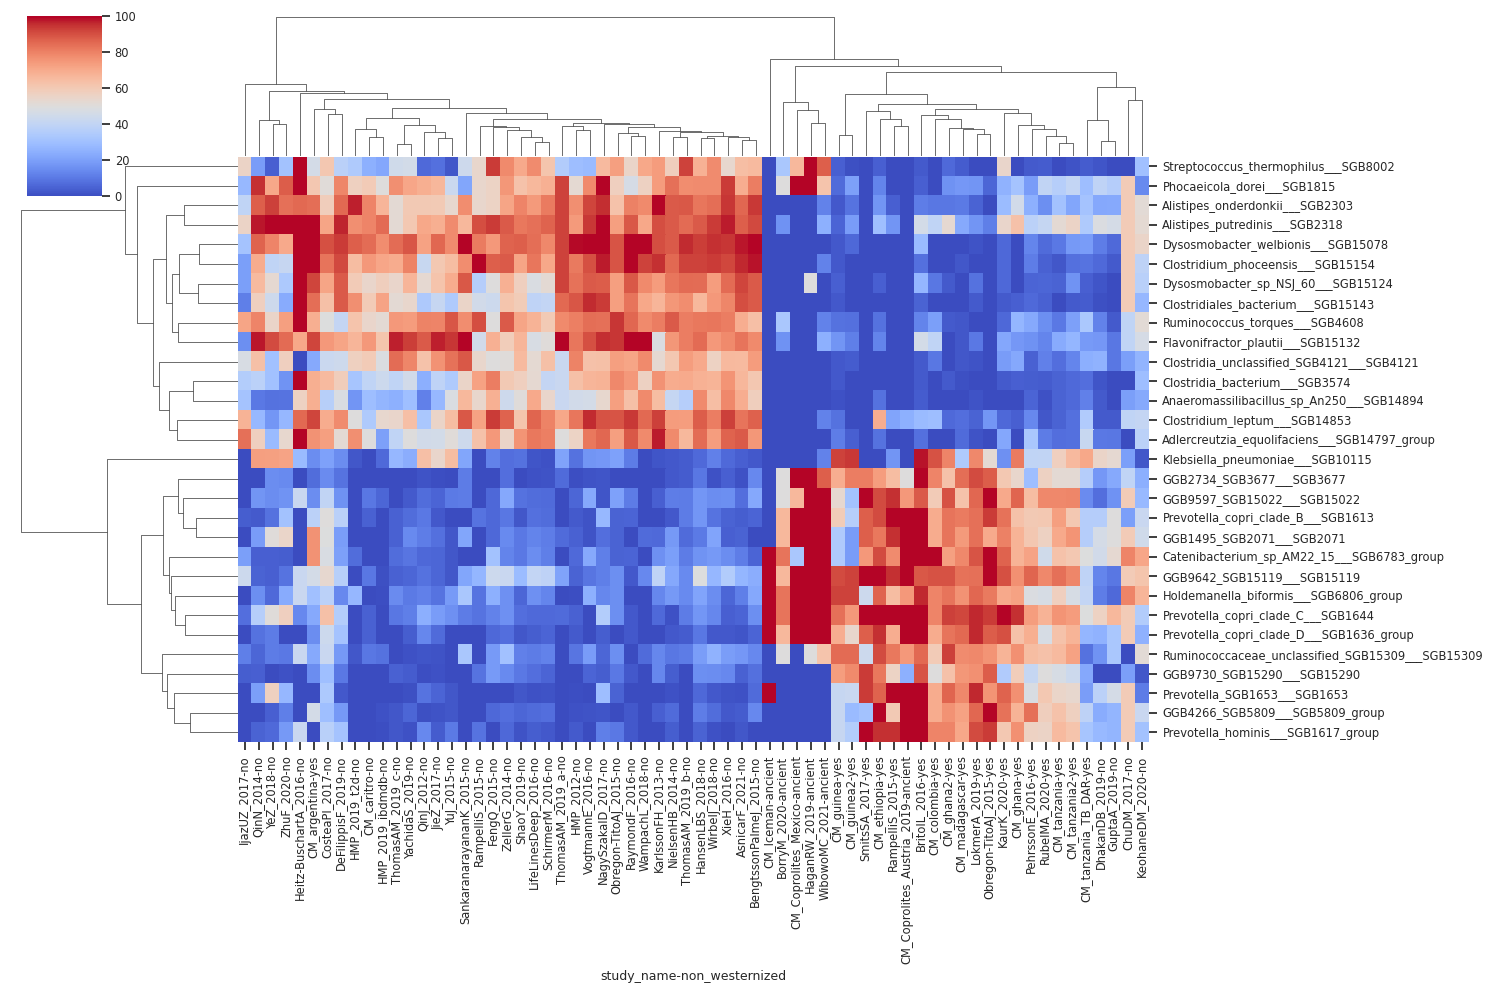

In [33]:
sns.set(font_scale=0.75)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [15, 7]
sns.clustermap(for_heatmap.transpose()[sample_selection], figsize=(15, 10), cmap='coolwarm', row_cluster=True)
# plt.pyplot.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/clustered_prevbact_heatmap.svg')

In [26]:
for_heatmap.transpose()[sample_selection]

study_name,AsnicarF_2021,BengtssonPalmeJ_2015,CM_caritro,ChuDM_2017,CosteaPI_2017,DeFilippisF_2019,DhakanDB_2019,FengQ_2015,GuptaA_2019,HMP_2012,...,PehrssonE_2016,RampelliS_2015,RubelMA_2020,SmitsSA_2017,BorryM_2020,CM_Coprolites_Austria_2019,CM_Coprolites_Mexico,CM_Iceman,HaganRW_2019,WibowoMC_2021
non_westernized,no,no,no,no,no,no,no,no,no,no,...,yes,yes,yes,yes,ancient,ancient,ancient,ancient,ancient,ancient
Prevotella_copri_clade_C___SGB1644,5.828780,15.714286,5.0,60.0,63.681592,36.082474,56.818182,12.50,66.666667,4.761905,...,74.166667,100.000000,68.292683,100.00,83.333333,100.0,100.000000,100.0,100.0,100.0
GGB2734_SGB3677___SGB3677,1.457195,14.285714,0.0,40.0,14.925373,9.278351,18.181818,0.00,23.333333,0.680272,...,30.000000,65.217391,57.317073,81.25,50.000000,50.0,100.000000,0.0,100.0,87.5
Prevotella_copri_clade_D___SGB1636_group,2.094718,5.714286,5.0,60.0,43.781095,31.958763,26.136364,6.25,33.333333,3.401361,...,69.166667,69.565217,47.560976,87.50,66.666667,100.0,100.000000,100.0,100.0,100.0
GGB4266_SGB5809___SGB5809_group,3.642987,14.285714,0.0,60.0,30.348259,18.556701,23.863636,6.25,26.666667,1.360544,...,84.166667,60.869565,58.536585,31.25,0.000000,100.0,0.000000,0.0,0.0,0.0
Prevotella_copri_clade_B___SGB1613,4.189435,5.714286,5.0,20.0,50.746269,38.144330,36.363636,6.25,50.000000,3.401361,...,60.833333,100.000000,60.975610,87.50,66.666667,100.0,100.000000,0.0,100.0,100.0
Prevotella_hominis___SGB1617_group,2.459016,0.000000,0.0,60.0,37.810945,31.958763,28.409091,0.00,26.666667,3.401361,...,56.666667,95.652174,56.097561,100.00,0.000000,100.0,0.000000,0.0,0.0,0.0
Prevotella_SGB1653___SGB1653,1.548270,7.142857,0.0,60.0,34.328358,3.092784,38.636364,0.00,46.666667,0.680272,...,48.333333,100.000000,60.975610,93.75,0.000000,100.0,0.000000,100.0,0.0,0.0
Holdemanella_biformis___SGB6806_group,11.839709,22.857143,0.0,80.0,38.308458,14.432990,11.363636,25.00,6.666667,0.680272,...,49.166667,65.217391,47.560976,43.75,83.333333,75.0,100.000000,100.0,100.0,100.0
GGB9730_SGB15290___SGB15290,4.918033,8.571429,0.0,20.0,30.348259,10.309278,0.000000,18.75,0.000000,0.000000,...,41.666667,56.521739,50.000000,93.75,0.000000,25.0,0.000000,0.0,0.0,0.0


In [27]:
test_prev = filtered_adults_abundances.astype(bool).astype(int)
prev_rate = test_prev.sum(axis=1) / test_prev.shape[1]

In [28]:
prev_rate[nw]

Prevotella_copri_clade_C___SGB1644                  0.255715
GGB2734_SGB3677___SGB3677                           0.142878
Prevotella_copri_clade_D___SGB1636_group            0.174971
GGB4266_SGB5809___SGB5809_group                     0.175703
Prevotella_copri_clade_B___SGB1613                  0.201641
Prevotella_hominis___SGB1617_group                  0.163101
Prevotella_SGB1653___SGB1653                        0.152843
Holdemanella_biformis___SGB6806_group               0.243406
GGB9730_SGB15290___SGB15290                         0.158265
Catenibacterium_sp_AM22_15___SGB6783_group          0.237544
GGB9597_SGB15022___SGB15022                         0.195780
GGB9642_SGB15119___SGB15119                         0.370018
Klebsiella_pneumoniae___SGB10115                    0.229338
Ruminococcaceae_unclassified_SGB15309___SGB15309    0.232122
GGB1495_SGB2071___SGB2071                           0.220399
dtype: float64

In [29]:
# for_heatmap.transpose()[sample_selection].to_csv("/shares/CIBIO-Storage/CM/scratch/users/sebastiaan.valkiers/wnw/data/heatmap_meandiff.tsv", sep="\t")
for_heatmap.transpose()[sample_selection]

study_name,AsnicarF_2021,BengtssonPalmeJ_2015,CM_caritro,ChuDM_2017,CosteaPI_2017,DeFilippisF_2019,DhakanDB_2019,FengQ_2015,GuptaA_2019,HMP_2012,...,PehrssonE_2016,RampelliS_2015,RubelMA_2020,SmitsSA_2017,BorryM_2020,CM_Coprolites_Austria_2019,CM_Coprolites_Mexico,CM_Iceman,HaganRW_2019,WibowoMC_2021
non_westernized,no,no,no,no,no,no,no,no,no,no,...,yes,yes,yes,yes,ancient,ancient,ancient,ancient,ancient,ancient
Prevotella_copri_clade_C___SGB1644,5.828780,15.714286,5.0,60.0,63.681592,36.082474,56.818182,12.50,66.666667,4.761905,...,74.166667,100.000000,68.292683,100.00,83.333333,100.0,100.000000,100.0,100.0,100.0
GGB2734_SGB3677___SGB3677,1.457195,14.285714,0.0,40.0,14.925373,9.278351,18.181818,0.00,23.333333,0.680272,...,30.000000,65.217391,57.317073,81.25,50.000000,50.0,100.000000,0.0,100.0,87.5
Prevotella_copri_clade_D___SGB1636_group,2.094718,5.714286,5.0,60.0,43.781095,31.958763,26.136364,6.25,33.333333,3.401361,...,69.166667,69.565217,47.560976,87.50,66.666667,100.0,100.000000,100.0,100.0,100.0
GGB4266_SGB5809___SGB5809_group,3.642987,14.285714,0.0,60.0,30.348259,18.556701,23.863636,6.25,26.666667,1.360544,...,84.166667,60.869565,58.536585,31.25,0.000000,100.0,0.000000,0.0,0.0,0.0
Prevotella_copri_clade_B___SGB1613,4.189435,5.714286,5.0,20.0,50.746269,38.144330,36.363636,6.25,50.000000,3.401361,...,60.833333,100.000000,60.975610,87.50,66.666667,100.0,100.000000,0.0,100.0,100.0
Prevotella_hominis___SGB1617_group,2.459016,0.000000,0.0,60.0,37.810945,31.958763,28.409091,0.00,26.666667,3.401361,...,56.666667,95.652174,56.097561,100.00,0.000000,100.0,0.000000,0.0,0.0,0.0
Prevotella_SGB1653___SGB1653,1.548270,7.142857,0.0,60.0,34.328358,3.092784,38.636364,0.00,46.666667,0.680272,...,48.333333,100.000000,60.975610,93.75,0.000000,100.0,0.000000,100.0,0.0,0.0
Holdemanella_biformis___SGB6806_group,11.839709,22.857143,0.0,80.0,38.308458,14.432990,11.363636,25.00,6.666667,0.680272,...,49.166667,65.217391,47.560976,43.75,83.333333,75.0,100.000000,100.0,100.0,100.0
GGB9730_SGB15290___SGB15290,4.918033,8.571429,0.0,20.0,30.348259,10.309278,0.000000,18.75,0.000000,0.000000,...,41.666667,56.521739,50.000000,93.75,0.000000,25.0,0.000000,0.0,0.0,0.0


### Checking numbers

In [30]:
w_enr = lm_results[lm_results['z-score'] < 0].sort_values('z-score').index.to_list()
nw_enr = lm_results[lm_results['z-score'] > 0].sort_values('z-score').index.to_list()

k_w,u_w,k_nw,u_nw = 0,0,0,0

for species,diff in species2meandif.items():
    if lm_results.loc[species]['q-value'] < 0.01:
        if diff > 0.20:
            if '_SGB' in species.split('__')[0]:
                u_w += 1
            else:
                k_w += 1
        elif diff < -0.2:
            if '_SGB' in species.split('__')[0]:
                u_nw += 1
            else:
                k_nw += 1

print('Total W', u_w+k_w)
print('kSGBs W',k_w)
print('uSGBs W',u_w,'\n')
print('Total NW',u_nw+k_nw)
print('kSGBs NW',k_nw)
print('uSGBs NW',u_nw)

Total W 136
kSGBs W 111
uSGBs W 25 

Total NW 216
kSGBs NW 106
uSGBs NW 110


### Add bolivian samples (NOT TO RUN)

In [170]:
bolivia = pd.read_csv('/shares/CIBIO-Storage/CM/scratch/data/meta/CM_bolivia/metaphlan-4.beta.1_vJan21_CHOCOPhlAnSGB_202103.tsv', index_col=[0], skiprows=[0], sep='\t')
keep = []
for x in bolivia.index.tolist():
    keep.append('t__' in x)
bolivia = bolivia.loc[keep]
bolivia.index = [x.split('|')[-2][3:].replace('_',' ') + ' (' + x.split('|')[-1][3:].replace('_',' ') +')' for x in bolivia.index.tolist()]
bolivia = bolivia.loc[[x for x in for_heatmap.columns if x in bolivia.index.tolist()]]
for s in [x for x in for_heatmap.columns if x not in bolivia.index.tolist()]:
    bolivia.loc[s] = 0
bolivia = bolivia.reindex(for_heatmap.columns.tolist())
bolivia

,BOL_LP-2,BOL_LP-3,BOL_N-01,BOL_N-02,BOL_N-03,BOL_N-04,BOL_N-05,BOL_N-06,BOL_N-07,BOL_N-08,...,BOL_Q-44,BOL_SV-01,BOL_SV-03,BOL_SV-05,BOL_SV-06,BOL_SV-10,BOL_SV-11,BOL_SV-16,BOL_SV-19,BOL_SV-22
Prevotella copri clade C (SGB1644),3.12987,0.00000,16.62939,0.00000,0.00000,1.17899,0.00000,0.00000,18.79016,7.35970,...,0.91957,0.00000,14.72808,4.81316,1.06986,14.45630,0.00000,0.00000,0.00000,8.07467
Prevotella copri clade D (SGB1636 group),0.37356,0.00000,4.92843,0.00000,0.00000,0.00000,0.00000,0.00082,5.63269,0.00000,...,0.01493,0.00000,0.00000,0.00000,2.17764,0.00000,4.71245,0.00000,0.00000,0.00000
Prevotella copri clade B (SGB1613),0.42083,0.00000,0.00000,0.00000,0.00000,1.42275,0.00000,0.06297,0.02583,0.00000,...,0.15305,1.70597,0.76299,2.64213,0.91260,4.65402,0.00000,0.00000,8.01315,7.59402
GGB9642 SGB15119 (SGB15119),0.49444,0.01782,0.05022,0.70581,0.26689,0.51589,0.00000,0.42021,0.00000,0.40909,...,0.52003,0.37175,0.15171,0.28379,0.18436,0.00000,0.26096,0.00000,0.20026,0.00000
GGB2734 SGB3677 (SGB3677),0.50002,0.00000,0.00000,0.00000,13.22153,8.21466,0.00000,0.00000,0.00000,0.00000,...,0.46944,0.00000,7.04089,17.68779,5.89623,0.00000,10.39289,15.45244,0.00000,0.00000
Prevotella hominis (SGB1617 group),2.28545,0.00000,9.39835,0.00000,0.00000,0.00000,0.00000,0.00000,10.70370,0.00000,...,5.74293,0.00000,0.00000,0.25776,0.56364,0.00000,0.92521,0.00000,0.00000,0.00000
GGB4266 SGB5809 (SGB5809 group),1.00357,0.00000,0.00000,0.00000,0.00000,0.00000,0.75406,0.00418,0.00028,0.00000,...,0.71572,0.00000,2.77899,3.06813,0.00000,1.73400,0.00000,0.00000,1.05309,0.00000
GGB9597 SGB15022 (SGB15022),0.47056,0.00000,0.00125,0.48747,0.02181,0.06029,0.03228,0.04342,0.00000,0.01804,...,0.34759,0.04278,0.01287,0.00455,0.06836,0.03396,0.04904,0.01206,0.05402,0.00000
Prevotella SGB1653 (SGB1653),0.06122,0.00000,3.21784,0.00000,0.00000,0.04957,0.00000,0.00000,3.48598,0.00000,...,0.01227,0.00000,0.00000,1.42808,0.00000,0.00000,0.00000,0.00000,0.00000,0.01955
GGB9603 SGB15035 (SGB15035),0.11004,0.00000,0.00000,0.00000,0.00000,0.01157,0.00000,0.00000,0.00000,0.02389,...,0.18391,0.13087,0.00000,0.06510,0.11783,0.01236,0.05314,0.02097,0.03048,0.00000


In [171]:
bolivia_prev = dict()
for x in set([x.split('_')[1].split('-')[0] for x in bolivia.columns.tolist()]):
    bolivia_prev[x] = 100 * bolivia[[y for y in bolivia.columns if '_{}-'.format(x) in y]].astype(bool).astype(int).T.sum() / bolivia[[y for y in bolivia.columns if '_{}-'.format(x) in y]].astype(bool).astype(int).T.count()

In [172]:
to_add_samples = list()
for_heatmap2 = for_heatmap.copy()
for x in bolivia_prev:
    tmp_df = pd.DataFrame(bolivia_prev[x]).T
    tmp_df.index=[('CM_Bolivia_{}'.format(x),'yes')]
    to_add_samples.append(('CM_Bolivia_{}'.format(x),'yes'))
    for_heatmap2 = for_heatmap2.append(tmp_df)

In [186]:
print(len({x:y for x,y in species2meandif_r.items() if y>20 and 'SGB' in x.split('___')[0]}))
# print(len({x:y for x,y in species2meandif_r.items() if y>20}))

20


In [42]:
prev_dif = pd.DataFrame.from_dict(species2meandif_r, orient='index', columns=['prevalence_dif'])
prev_dif.to_csv('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_prev_dif_sgb.tsv', sep='\t')
prev_dif

,prevalence_dif
Dysosmobacter_welbionis___SGB15078,71.030310
Clostridium_phoceensis___SGB15154,65.867947
Ruminococcus_torques___SGB4608,56.740952
Dysosmobacter_sp_NSJ_60___SGB15124,55.351201
Alistipes_onderdonkii___SGB2303,54.429805
...,...
GGB2734_SGB3677___SGB3677,-58.916709
GGB9642_SGB15119___SGB15119,-60.660726
Prevotella_copri_clade_B___SGB1613,-60.680576
Prevotella_copri_clade_D___SGB1636_group,-62.438118


In [98]:
for_heatmap.columns = [x.replace('___' , ' (').replace('_', ' ')+')' for x in for_heatmap.columns]

In [31]:
sns.set(font_scale=0.75)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
sns.clustermap(for_heatmap2.transpose()[sample_selection + to_add_samples], figsize=(15, 10), cmap='coolwarm')
# plt.pyplot.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/clustered_heatmap_bolivia.svg')

NameError: name 'for_heatmap2' is not defined

## From here did not check

## Heatmap rel ab

In [284]:
nw = list(species2meandif.keys())[0:15]
species2meandif_r = {k: v for k, v in sorted(species2meandif.items(), reverse=True, key=lambda item: item[1])}
w = list(species2meandif_r.keys())[0:15]
enr_abundances = adults_abundances_f.loc[nw+w]
adults_prevs = enr_abundances.copy().transpose().astype(bool).astype(int)
min_val = enr_abundances[enr_abundances != 0].min().min()
# enr_abundances = enr_abundances + min_val
# enr_abundances = enr_abundances.applymap(math.log10)
adults_abs = enr_abundances.transpose()
adults_metadata_heatmap = adults_metadata[adults_metadata['study_name'] != 'CM_china']
adults_metadata_heatmap = adults_metadata_heatmap[adults_metadata_heatmap['study_name'] != 'HanniganGD_2017']
for_heatmap = (adults_metadata_heatmap[['study_name', 'non_westernized']].transpose().append(adults_abs.transpose()).transpose().groupby(['study_name', 'non_westernized']).sum() / adults_metadata_heatmap[['study_name', 'non_westernized']].transpose().append(adults_prevs.transpose()).transpose().groupby(['study_name', 'non_westernized']).count())
sample_selection = [(x,y) for x,y in for_heatmap.transpose().columns if y=='no'] + [(x,y) for x,y in for_heatmap.transpose().columns if y=='yes'] + [(x,y) for x,y in for_heatmap.transpose().columns if y=='ancient']
for_heatmap.columns = [x.replace('___' , ' (').replace('_', ' ')+')' for x in for_heatmap.columns]

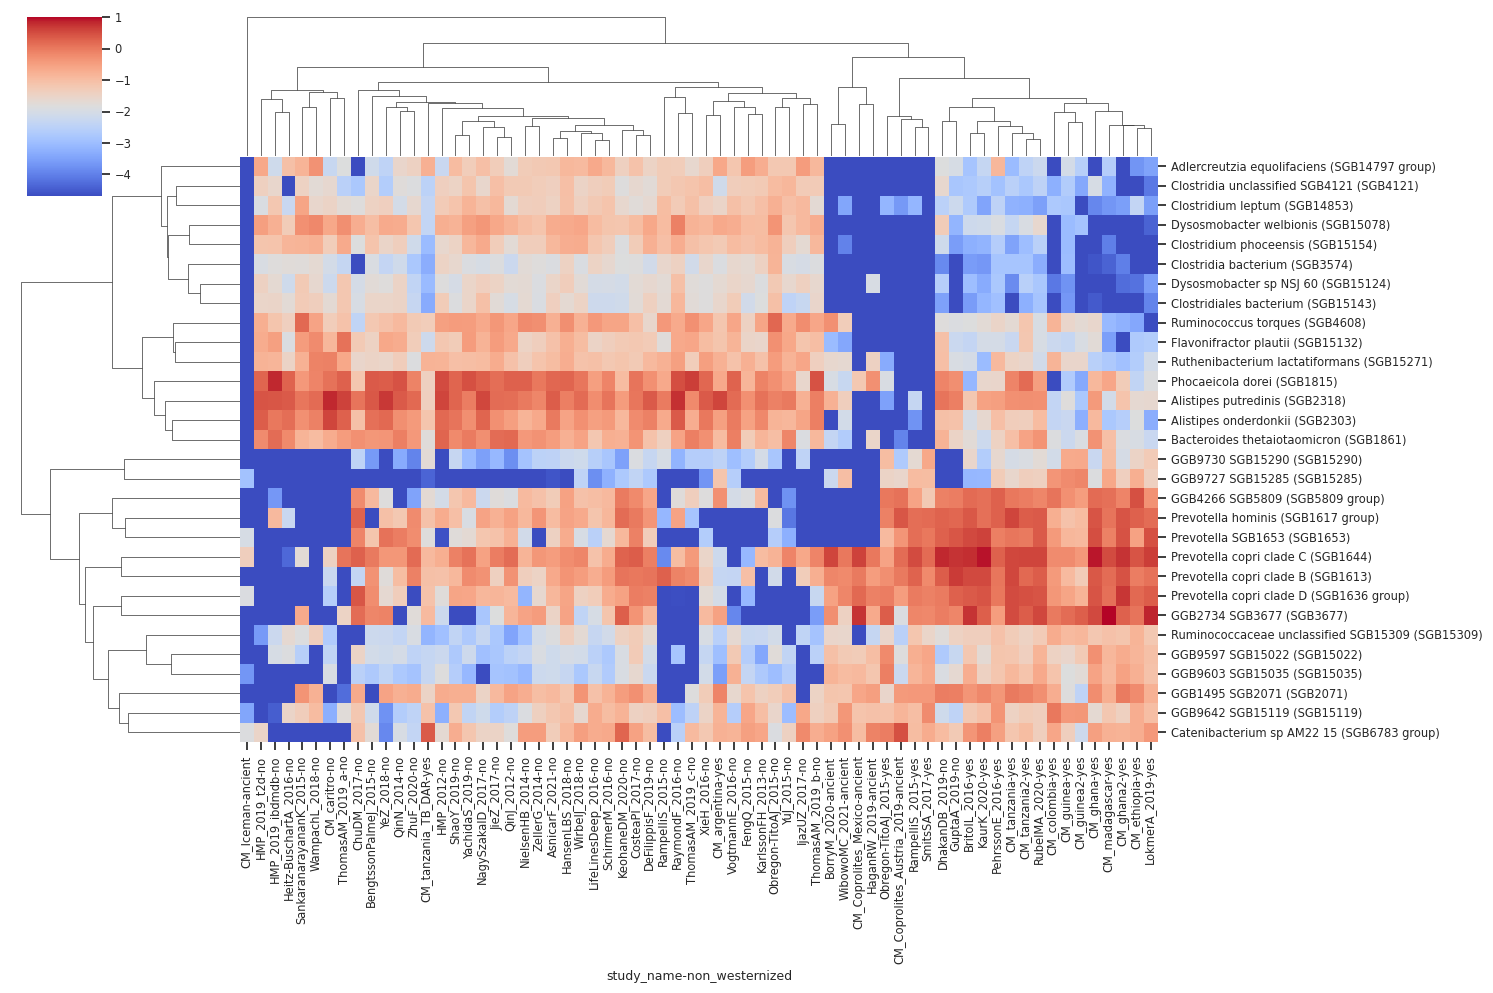

In [285]:
sns.set(font_scale=0.75)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
sns.clustermap((for_heatmap.fillna(0) + min_val).applymap(math.log10).transpose()[sample_selection], figsize=(15, 10), cmap='coolwarm')
plt.pyplot.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/clustered_heatmap.svg')

## Phylum

In [157]:
import bz2
phylum = dict()
with bz2.open('/shares/CIBIO-Storage/CM/scratch/databases/MetaRefSGB/releases/Jan21/SGB.Jan21.txt.bz2', 'rt') as read_file:
    for line in read_file:
        if line.startswith('SGB'):
            line = line.strip().split('\t')
            phylum[line[1]] = line[9].split('|')[1].replace('p__','')
        elif line.startswith('GGB'):
            break

In [160]:
{x:phylum[x.split('(')[-1][:-1].replace(' group', '')[3:]] for x in for_heatmap.columns}

{'Prevotella copri clade C (SGB1644)': 'Bacteroidetes',
 'Prevotella copri clade D (SGB1636 group)': 'Bacteroidetes',
 'GGB9642 SGB15119 (SGB15119)': 'Firmicutes',
 'Prevotella copri clade B (SGB1613)': 'Bacteroidetes',
 'GGB2734 SGB3677 (SGB3677)': 'Proteobacteria',
 'Prevotella hominis (SGB1617 group)': 'Bacteroidetes',
 'GGB4266 SGB5809 (SGB5809 group)': 'Firmicutes',
 'GGB9597 SGB15022 (SGB15022)': 'Firmicutes',
 'Prevotella SGB1653 (SGB1653)': 'Bacteroidetes',
 'GGB9603 SGB15035 (SGB15035)': 'Firmicutes',
 'Catenibacterium sp AM22 15 (SGB6783 group)': 'Firmicutes',
 'Ruminococcaceae unclassified SGB15309 (SGB15309)': 'Firmicutes',
 'GGB1495 SGB2071 (SGB2071)': 'Bacteroidetes',
 'GGB9730 SGB15290 (SGB15290)': 'Firmicutes',
 'GGB9727 SGB15285 (SGB15285)': 'Firmicutes',
 'Dysosmobacter welbionis (SGB15078)': 'Firmicutes',
 'Clostridium phoceensis (SGB15154)': 'Firmicutes',
 'Ruminococcus torques (SGB4608)': 'Firmicutes',
 'Dysosmobacter sp NSJ 60 (SGB15124)': 'Firmicutes',
 'Alistipe

## Genus level analysis

In [24]:
keep = list()
for x in abundances.index.tolist():
    keep.append('g__' in x and 's__' not in x)
genus_abundances = abundances.loc[keep]
genus_abundances

,MMRS62666492ST-27-0-0,MMRS51737257ST-27-0-0,MMRS38861560ST-27-0-0,MMRS95674036ST-27-0-0,MMRS67096717ST-27-0-0,MMRS84085284ST-27-0-0,MMRS51307502ST-27-0-0,MMRS17963147ST-27-0-0,MMRS39582183ST-27-0-0,MMRS35808664ST-27-0-0,...,SID15785561_SF07,SID19401504_SF05,SID20269046_SF08,SID50492523_SF07,SID10502288_SF08,SID72242320_SF07,SID30920067_SF07,SID11486372_SF08,SID16913125_SF05,SID16853657_SF05
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Prevotellaceae|g__Prevotella,11.54777,6.66955,0.00561,0.00000,0.00000,9.73808,0.00234,0.00080,5.30270,28.78837,...,0.00000,0.00000,1.29178,0.00000,0.44391,0.00000,24.37621,0.00000,0.00000,0.00000
k__Bacteria|p__Firmicutes|c__Clostridia|o__Clostridiales|f__Ruminococcaceae|g__Ruminococcus,7.52700,0.79734,8.12303,0.00000,7.75296,9.57907,0.20778,2.05633,0.26778,1.80141,...,2.12302,2.17692,7.91993,7.55420,3.34036,3.77692,4.62001,3.63874,12.28899,2.33764
k__Bacteria|p__Firmicutes|c__Clostridia|o__Clostridiales|f__Lachnospiraceae|g__Coprococcus,5.71097,6.70054,1.73373,0.00000,0.42493,0.06011,1.34608,0.11450,1.14001,0.95855,...,0.61725,0.05870,1.92340,0.16151,0.52430,2.75613,6.39637,0.03996,5.24635,0.52179
k__Bacteria|p__Firmicutes|c__Clostridia|o__Clostridiales|f__Ruminococcaceae|g__Ruminococcaceae_unclassified,5.41571,5.73135,2.25844,0.24434,0.90568,0.36558,3.38228,14.66346,1.97741,1.53341,...,7.48829,6.15428,2.21527,4.15280,5.24223,7.30798,2.74022,6.29617,4.51280,0.86110
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Bacteroidaceae|g__Bacteroides,5.09787,7.09113,9.27670,27.98616,6.76791,14.77279,2.51068,13.58390,1.18366,6.54012,...,24.84529,18.59196,1.79053,14.09464,6.25618,6.72498,2.20520,6.47708,7.19272,15.95693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Bacteroidales_unclassified|g__GGB27885,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Odoribacteraceae|g__GGB28250,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
k__Bacteria|p__Bacteroidetes|c__CFGB4425|o__OFGB4425|f__FGB4425|g__GGB27924,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000


In [25]:
adults_metadata = metadata[metadata['age'] != pd.NA]
adults_metadata = adults_metadata[adults_metadata['age'] != np.nan]
adults_metadata = adults_metadata[adults_metadata['age'].notna()]
adults_metadata = adults_metadata[adults_metadata['age'] != '1.083.333.333']
adults_metadata['age'] = adults_metadata['age'].astype(float)
adults_metadata = adults_metadata[adults_metadata['age'] > 16]
adults_metadata = adults_metadata[adults_metadata['study_name'] != 'HanniganGD_2017']
m = pd.DataFrame(metadata)
ancient = m[m['non_westernized'] == 'ancient']
ancient = ancient[ancient['study_name'] != 'RifkinRF_2020']
adults_metadata = adults_metadata.append(ancient)
adults_metadata.index = adults_metadata['sample_id']
adults_metadata

,study_name,sample_id,subject_id,body_site,antibiotics_current_use,study_condition,disease,age,age_category,gender,...,non_westernized,sequencing_platform,PMID,number_reads,number_bases,minimum_read_length,median_read_length,NCBI_accession,curator,DNA_extraction_kit
sample_id,,,,,,,,,,,,,,,,,,,,,
O2_UC49_0,NielsenHB_2014,O2_UC49_0,O2_UC49,stool,NaN,control,healthy,22.0,adult,female,...,no,IlluminaHiSeq,24997787.0,60584637.0,4.099972e+09,30.0,70.0,ERR210493;ERR210492;ERR209641;ERR209640,Paolo_Manghi,NaN
O2_UC49_2,NielsenHB_2014,O2_UC49_2,O2_UC49,stool,NaN,control,healthy,22.0,adult,female,...,no,IlluminaHiSeq,24997787.0,56508214.0,3.775477e+09,30.0,70.0,ERR210495;ERR210494;ERR209643;ERR209642,Paolo_Manghi,NaN
O2_UC50_0,NielsenHB_2014,O2_UC50_0,O2_UC50,stool,NaN,control,healthy,24.0,adult,male,...,no,IlluminaHiSeq,24997787.0,65105855.0,4.392995e+09,30.0,71.0,ERR210497;ERR210496;ERR209645;ERR209644,Paolo_Manghi,NaN
O2_UC50_2,NielsenHB_2014,O2_UC50_2,O2_UC50,stool,NaN,control,healthy,24.0,adult,male,...,no,IlluminaHiSeq,24997787.0,53260679.0,3.596382e+09,30.0,70.0,ERR210500;ERR209648,Paolo_Manghi,NaN
O2_UC51_0,NielsenHB_2014,O2_UC51_0,O2_UC51,stool,NaN,control,healthy,32.0,adult,female,...,no,IlluminaHiSeq,24997787.0,57486896.0,3.923766e+09,30.0,72.0,ERR210502;ERR210501;ERR209650;ERR209649,Paolo_Manghi,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SAMEA6415059,BorryM_2020,SAMEA6415059,SAMEA6415059,stool,NaN,control,healthy,NaN,NaN,NaN,...,ancient,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ERR3761407,BorryM_2020,ERR3761407,ERR3761407,stool,NaN,control,healthy,NaN,NaN,NaN,...,ancient,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ERR3761411,BorryM_2020,ERR3761411,ERR3761411,stool,NaN,control,healthy,NaN,NaN,NaN,...,ancient,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
genus_abundances = [x.split('|')[-1][3:].replace('_','') for x in genus_abundances.index.tolist()]
genus_abundances

['Prevotella',
 'Ruminococcus',
 'Coprococcus',
 'Ruminococcaceaeunclassified',
 'Bacteroides',
 'Alistipes',
 'Faecalibacterium',
 'Clostridiaunclassified',
 'Phocaeicola',
 'Clostridium',
 'GGB3226',
 'Bacilliunclassified',
 'Dialister',
 'Roseburia',
 'Lachnospiraceaeunclassified',
 'GGB9602',
 'GGB4569',
 'GGB9758',
 'Oscillibacter',
 'Odoribacter',
 'Lachnospira',
 'GGB3256',
 'Parabacteroides',
 'GGB9634',
 'GGB9615',
 'GGB9635',
 'GGB9677',
 'CandidatusCibiobacter',
 'GGB3614',
 'Gemmiger',
 'Dorea',
 'GGB9342',
 'Clostridiaceaeunclassified',
 'Mediterraneibacter',
 'GGB4769',
 'Intestinibacter',
 'Blautia',
 'Phascolarctobacterium',
 'GGB9176',
 'Akkermansia',
 'GGB9632',
 'Firmicutesunclassified',
 'GGB9512',
 'GGB9774',
 'Streptococcus',
 'Clostridialesunclassified',
 'Duodenibacillus',
 'Rikenellaceaeunclassified',
 'GGB9524',
 'Lacrimispora',
 'Eubacterium',
 'Faecalibacillus',
 'Eubacteriaceaeunclassified',
 'GGB9712',
 'Veillonella',
 'GGB9705',
 'Bacteroidalesunclassifie

In [26]:
genus_adults_abundances = genus_abundances[adults_metadata['sample_id']]
genus_adults_abundances = genus_adults_abundances.drop(genus_adults_abundances.loc[genus_adults_abundances.sum(axis=1) == 0].index.tolist())
genus_adults_abundances = genus_adults_abundances.transpose()
genus_adults_abundances = genus_adults_abundances.drop(genus_adults_abundances.loc[genus_adults_abundances.sum(axis=1) == 0].index.tolist())
genus_adults_abundances = genus_adults_abundances.transpose()
genus_adults_abundances

,O2_UC49_0,O2_UC49_2,O2_UC50_0,O2_UC50_2,O2_UC51_0,O2_UC51_2,O2_UC52_0,O2_UC53_0,O2_UC53_2,O2_UC54_0,...,AZ110A,Zape3,ERR3761413,ERR3761410,ERR3761412,SAMEA6415059,ERR3761407,ERR3761411,Zape5,Zape28
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Prevotellaceae|g__Prevotella,9.05103,0.03919,4.27695,6.76708,0.01102,0.00000,3.01820,0.00000,0.00000,0.00000,...,13.63729,5.96162,32.64522,31.81368,2.54772,1.53589,0.00000,11.07995,1.42653,7.14128
k__Bacteria|p__Firmicutes|c__Clostridia|o__Clostridiales|f__Ruminococcaceae|g__Ruminococcus,0.05512,1.74137,7.90760,5.41295,5.38731,5.11773,7.88251,5.20539,4.30496,7.17665,...,1.16029,1.08471,0.02310,4.10175,0.28891,1.51309,0.00000,0.48171,0.83320,0.25749
k__Bacteria|p__Firmicutes|c__Clostridia|o__Clostridiales|f__Lachnospiraceae|g__Coprococcus,1.11919,0.51897,0.86328,0.62230,4.35674,2.85328,0.19576,1.67110,0.70936,1.12890,...,0.77701,3.96252,0.67126,1.08955,0.33808,0.04353,0.27543,0.43376,0.24393,0.43134
k__Bacteria|p__Firmicutes|c__Clostridia|o__Clostridiales|f__Ruminococcaceae|g__Ruminococcaceae_unclassified,0.03390,4.22280,2.02940,3.03808,1.96203,2.54309,1.47287,0.09403,0.78964,0.40384,...,0.80664,4.11401,0.00000,0.04300,0.79837,11.05646,0.05562,2.42817,5.59645,4.71252
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Bacteroidaceae|g__Bacteroides,15.98495,17.54462,13.69035,10.09041,16.35998,12.38272,14.16702,3.89449,10.76603,9.83838,...,1.32461,0.10637,0.03293,0.04222,2.69388,0.16506,0.00484,0.15546,0.47138,0.12361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Carnobacteriaceae|g__Jeotgalibaca,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
k__Bacteria|p__Proteobacteria|c__Betaproteobacteria|o__Burkholderiales|f__Alcaligenaceae|g__Paracandidimonas,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
k__Bacteria|p__Firmicutes|c__Clostridia|o__Clostridiales|f__Clostridiales_unclassified|g__Proteiniborus,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000


In [38]:
filtered_adults_metadata = adults_metadata[['study_name', 'age', 'gender', 'non_westernized', 'number_reads']]
filtered_adults_metadata = filtered_adults_metadata.loc[genus_adults_abundances.columns]
filtered_adults_metadata = filtered_adults_metadata[filtered_adults_metadata['age'] != pd.NA]
filtered_adults_metadata = filtered_adults_metadata[filtered_adults_metadata['age'] != np.nan]
filtered_adults_metadata = filtered_adults_metadata[filtered_adults_metadata['age'].notna()]
filtered_adults_metadata = filtered_adults_metadata[filtered_adults_metadata['gender'] != pd.NA]
filtered_adults_metadata = filtered_adults_metadata[filtered_adults_metadata['gender'] != np.nan]
filtered_adults_metadata = filtered_adults_metadata[filtered_adults_metadata['gender'].notna()]
filtered_adults_metadata = filtered_adults_metadata[filtered_adults_metadata['number_reads'] != pd.NA]
filtered_adults_metadata = filtered_adults_metadata[filtered_adults_metadata['number_reads'] != np.nan]
filtered_adults_metadata = filtered_adults_metadata[filtered_adults_metadata['number_reads'].notna()]
filtered_adults_metadata = filtered_adults_metadata.transpose()
filtered_adults_metadata

,O2_UC49_0,O2_UC49_2,O2_UC50_0,O2_UC50_2,O2_UC51_0,O2_UC51_2,O2_UC52_0,O2_UC53_0,O2_UC53_2,O2_UC54_0,...,C16-20615-TZ,C16-20616-TZ,C16-20617-TZ,C16-20625-TZ,C16-20626-TZ,C16-20627-TZ,C16-20645-TZ,C16-20646-TZ,C16-20647-TZ,C16-20664-TZ
study_name,NielsenHB_2014,NielsenHB_2014,NielsenHB_2014,NielsenHB_2014,NielsenHB_2014,NielsenHB_2014,NielsenHB_2014,NielsenHB_2014,NielsenHB_2014,NielsenHB_2014,...,CM_tanzania2,CM_tanzania2,CM_tanzania2,CM_tanzania,CM_tanzania,CM_tanzania,CM_tanzania,CM_tanzania,CM_tanzania,CM_tanzania2
age,22.0,22.0,24.0,24.0,32.0,32.0,32.0,21.0,21.0,20.0,...,27.0,31.0,24.0,20.0,25.0,20.0,34.0,40.0,18.0,48.0
gender,female,female,male,male,female,female,female,male,male,male,...,female,male,female,female,male,male,female,male,female,male
non_westernized,no,no,no,no,no,no,no,no,no,no,...,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
number_reads,60584637.0,56508214.0,65105855.0,53260679.0,57486896.0,117575131.0,60333297.0,50010311.0,58698482.0,54368659.0,...,28965115.0,20811913.0,29903092.0,49299720.0,36316653.0,38426298.0,66130906.0,66850184.0,62136875.0,44148555.0


In [54]:
filtered_genus_abundances = genus_adults_abundances[filtered_adults_metadata.columns]
filtered_genus_abundances.index = [x.split('|')[-1][3:] for x in  filtered_genus_abundances.index.tolist()]
filtered_genus_abundances

,O2_UC49_0,O2_UC49_2,O2_UC50_0,O2_UC50_2,O2_UC51_0,O2_UC51_2,O2_UC52_0,O2_UC53_0,O2_UC53_2,O2_UC54_0,...,C16-20615-TZ,C16-20616-TZ,C16-20617-TZ,C16-20625-TZ,C16-20626-TZ,C16-20627-TZ,C16-20645-TZ,C16-20646-TZ,C16-20647-TZ,C16-20664-TZ
Prevotella,9.05103,0.03919,4.27695,6.76708,0.01102,0.00000,3.01820,0.00000,0.00000,0.00000,...,12.02556,13.41909,45.23977,33.24864,43.18827,16.46914,22.69218,39.58195,10.09199,5.91872
Ruminococcus,0.05512,1.74137,7.90760,5.41295,5.38731,5.11773,7.88251,5.20539,4.30496,7.17665,...,3.00661,3.88442,2.58935,0.89005,0.99054,2.74890,0.83500,0.37256,1.30715,4.05535
Coprococcus,1.11919,0.51897,0.86328,0.62230,4.35674,2.85328,0.19576,1.67110,0.70936,1.12890,...,0.08165,0.10218,0.55546,1.40130,0.09603,1.72426,0.20913,0.20610,0.34783,3.10933
Ruminococcaceae_unclassified,0.03390,4.22280,2.02940,3.03808,1.96203,2.54309,1.47287,0.09403,0.78964,0.40384,...,4.76847,5.07935,2.02354,1.05351,1.03007,4.95634,4.32821,2.40597,3.32645,1.94116
Bacteroides,15.98495,17.54462,13.69035,10.09041,16.35998,12.38272,14.16702,3.89449,10.76603,9.83838,...,2.29250,1.42325,0.03322,0.00000,0.00158,4.87599,0.00186,0.03902,0.00616,0.01430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Jeotgalibaca,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
Paracandidimonas,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
Proteiniborus,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
Propioniciclava,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000


In [55]:
data_table

,study_name,age,gender,non_westernized,number_reads,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Prevotellaceae|g__Prevotella
O2_UC49_0,NielsenHB_2014,22.0,female,no,60584637,1
O2_UC49_2,NielsenHB_2014,22.0,female,no,56508214,1
O2_UC50_0,NielsenHB_2014,24.0,male,no,65105855,1
O2_UC50_2,NielsenHB_2014,24.0,male,no,53260679,1
O2_UC51_0,NielsenHB_2014,32.0,female,no,57486896,1
...,...,...,...,...,...,...
C16-20627-TZ,CM_tanzania,20.0,male,yes,38426298,1
C16-20645-TZ,CM_tanzania,34.0,female,yes,66130906,1
C16-20646-TZ,CM_tanzania,40.0,male,yes,66850184,1
C16-20647-TZ,CM_tanzania,18.0,female,yes,62136875,1


In [59]:
p_values = list()
results = dict()
for species in filtered_genus_abundances.index.tolist():
    data_table = filtered_adults_metadata.append(filtered_genus_abundances.loc[species].transpose()).transpose()
    data_table[species] = data_table[species].astype(bool).astype(int)
    w = data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'no'].index][species]
    nw = data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'yes'].index][species]
    if ((w.sum() / len(w) >= 0.1) or (nw.sum() / len(nw) >= 0.1)) and not ((w.sum() / len(w) >= 0.9) and (nw.sum() / len(nw) >= 0.9)):    
        data_table['number_reads'] = data_table['number_reads'].astype(int)
        data_table['age'] = data_table['age'].astype(float)
#         data_table = data_table.transpose()
        model = BinomialBayesMixedGLM.from_formula('{} ~ non_westernized + age + C(gender)'.format(species), {"study": '0 + C(study_name)'}, data_table, vcp_p=.5)
        result = model.fit_map()
        S = result.summary()
        m = S.tables[0]["Post. Mean"]["non_westernized[T.yes]"]
        s = S.tables[0]["Post. SD"]["non_westernized[T.yes]"]
        z_value = m/s
        p_value = 2 * sts.norm.cdf(-np.abs(z_value))
        p_values.append(p_value)
        results[species] =  [z_value, p_value]
        print('{} {} {}'.format(species, z_value, p_value))

Prevotella 7.752162433354969 9.034072552104313e-15
Bacteroides -11.251736008837744 2.2707807895755097e-29
Alistipes -9.402645154986628 5.320828009146916e-21
Phocaeicola -10.74363669917947 6.34929800956256e-27
GGB3226 14.042951673965872 8.509330075309857e-45
Bacilli_unclassified 8.20589295640671 2.288832781676055e-16
Dialister -13.965612481255324 2.527234477769744e-44
GGB9602 5.876738496024222 4.184284082892979e-09
GGB4569 2.958007239157228 0.003096348522652307
GGB9758 3.9539040240518935 7.688626079023577e-05
Oscillibacter 4.952646887545235 7.321075438760545e-07
Odoribacter -7.4607584734207695 8.602581814408417e-14
Lachnospira -0.39396059283482915 0.6936101336451748
GGB3256 5.679425797448806 1.3514766299272403e-08
Parabacteroides -8.074712135301294 6.763601783770991e-16
GGB9634 8.135999731294213 4.085527192066912e-16
GGB9615 5.065778094573069 4.0673550991270163e-07
GGB9635 8.741071179356704 2.3091047041860766e-18
GGB9677 5.380178029918169 7.441221317942513e-08
Candidatus_Cibiobacter 3.3

Methanomassiliicoccales_unclassified 11.752828719816751 6.829375113910004e-32
GGB6612 -6.647327965336359 2.98461507422138e-11
GGB3490 -1.547111786939183 0.12183629216810532
GGB4566 -6.215951979846037 5.101440447619345e-10
GGB9691 9.268341216641732 1.8906322157327618e-20
GGB4603 0.5347935173572516 0.5927926462437255
Candidatus_Gastranaerophilales_unclassified 8.87645993021087 6.902198392145075e-19
Sutterella -2.3094158426028906 0.02092051673669094
GGB3433 -7.077493623934664 1.4678494405064745e-12
Pseudoruminococcus 2.8856351748290368 0.003906246743533899
Anaerotignum -0.5892013435373057 0.5557262159978167
GGB4599 2.3289369961647983 0.019862403652962084
GGB9361 6.612869258461236 3.769413502159521e-11
GGB3278 2.0238200420342225 0.04298867128078951
Enterocloster -8.780479627112227 1.6277899951180902e-18
Peptococcaceae_unclassified 6.403525859860903 1.518291249022982e-10
Eisenbergiella -9.17050958235418 4.7078820479685656e-20
Slackia 9.899283471804528 4.19268090616832e-23
Tyzzerella -1.4364

GGB1266 9.744716711996498 1.943200895030976e-22
GGB3341 14.6275636414389 1.8737769253816038e-48
GGB9727 14.087996105680359 4.5015466611820345e-45
GGB6567 9.604693282462545 7.638501010772959e-22
GGB9589 5.059600369125486 4.2013608196313636e-07
GGB1420 -6.07508732359076 1.239202681351871e-09
GGB6565 12.292792635000117 9.902496365664234e-35
Brachyspira 8.424518259057564 3.622375138509761e-17
GGB2983 10.523487931428308 6.73338301983395e-26
GGB9288 9.977590602680438 1.910495508252217e-23
GGB9642 12.05574578472842 1.8088771167517456e-33
GGB3632 10.777361037119974 4.403375487240839e-27
Propionibacterium 1.3155628158251869 0.18832082090613844
GGB1405 12.616825265064552 1.7055959041421556e-36
Megamonas -2.7820461498275773 0.005401735824419299
GGB6012 11.707043229263213 1.1729916902423628e-31
GGB3637 7.751474870153196 9.083132279268884e-15
GGB3737 5.7962833714325015 6.780066485841831e-09
GGB4768 2.804964019395469 0.0050322196841880934
GGB3623 15.28526498923103 9.587221778121409e-53
GGB4674 14.96

In [60]:
fdrs = statsmodels.stats.multitest.fdrcorrection(p_values)
lm_results = pd.DataFrame.from_dict(results).transpose()
lm_results.columns = ['z-score', 'p-value']
lm_results['q-value'] = fdrs[1]
lm_results.to_csv('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_bayesian_model_genus.tsv',sep='\t')

In [66]:
genus_adults_abundances.index = [x.split('|')[-1][3:] for x in  genus_adults_abundances.index.tolist()]

In [67]:
# Mean by study
species2meandif = dict()
for species in lm_results.index.tolist():
    data_table = filtered_adults_metadata.append(filtered_genus_abundances.loc[species].transpose()).transpose()
    data_table[species] = data_table[species].astype(bool).astype(int)
    w = statistics.mean((data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'no'].index].groupby('study_name')[species].sum() / data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'no'].index].groupby('study_name')[species].count() * 100).values)
    nw = statistics.mean((data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'yes'].index].groupby('study_name')[species].sum() / data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'yes'].index].groupby('study_name')[species].count() * 100).values)
    species2meandif[species] = w - nw
species2meandif = {k: v for k, v in sorted(species2meandif.items(), key=lambda item: item[1])}
species2meandif

{'GGB9642': -60.660725703596455,
 'GGB2734': -59.20391292987305,
 'GGB4266': -58.55705847379093,
 'GGB9597': -57.80243179732689,
 'GGB9603': -56.63295012763938,
 'Catenibacterium': -56.033663412614146,
 'Bacteroidaceae_unclassified': -55.679356180259624,
 'GGB1495': -54.39396343382129,
 'Senegalimassilia': -53.45917333834862,
 'GGB9727': -52.86682894085816,
 'GGB2983': -52.1874003526264,
 'GGB9595': -51.520032302378446,
 'GGB9593': -51.29236023071029,
 'Holdemanella': -51.081815424591454,
 'GGB4672': -49.02294881997486,
 'GGB1247': -48.448714971455054,
 'GGB6565': -48.39613243430259,
 'GGB1239': -47.8797341923222,
 'Alphaproteobacteria_unclassified': -47.76575736130764,
 'GGB38171': -47.606382838371296,
 'Coriobacteriales_unclassified': -47.595883657164926,
 'Slackia': -46.307980702114975,
 'GGB9631': -46.1598746508179,
 'GGB1250': -45.83811022191596,
 'GGB1266': -45.80096143470675,
 'GGB1235': -45.2344613415239,
 'GGB49418': -45.09768567427776,
 'GGB1380': -43.85341554060579,
 'GGB311

In [69]:
adults_metadata_heatmap = adults_metadata[adults_metadata['study_name'] != 'CM_china']
adults_metadata_heatmap = adults_metadata_heatmap[adults_metadata_heatmap['study_name'] != 'HanniganGD_2017']
nw = list(species2meandif.keys())[0:15]
species2meandif_r = {k: v for k, v in sorted(species2meandif.items(), reverse=True, key=lambda item: item[1])}
w = list(species2meandif_r.keys())[0:15]
enr_abundances = genus_adults_abundances.loc[nw+w]
adults_prevs = enr_abundances.transpose().astype(bool).astype(int)
for_heatmap = (adults_metadata_heatmap[['study_name', 'non_westernized']].transpose().append(adults_prevs.transpose()).transpose().groupby(['study_name', 'non_westernized']).sum() / adults_metadata_heatmap[['study_name', 'non_westernized']].transpose().append(adults_prevs.transpose()).transpose().groupby(['study_name', 'non_westernized']).count()) * 100
sample_selection = [(x,y) for x,y in for_heatmap.transpose().columns if y=='no'] + [(x,y) for x,y in for_heatmap.transpose().columns if y=='yes'] + [(x,y) for x,y in for_heatmap.transpose().columns if y=='ancient']

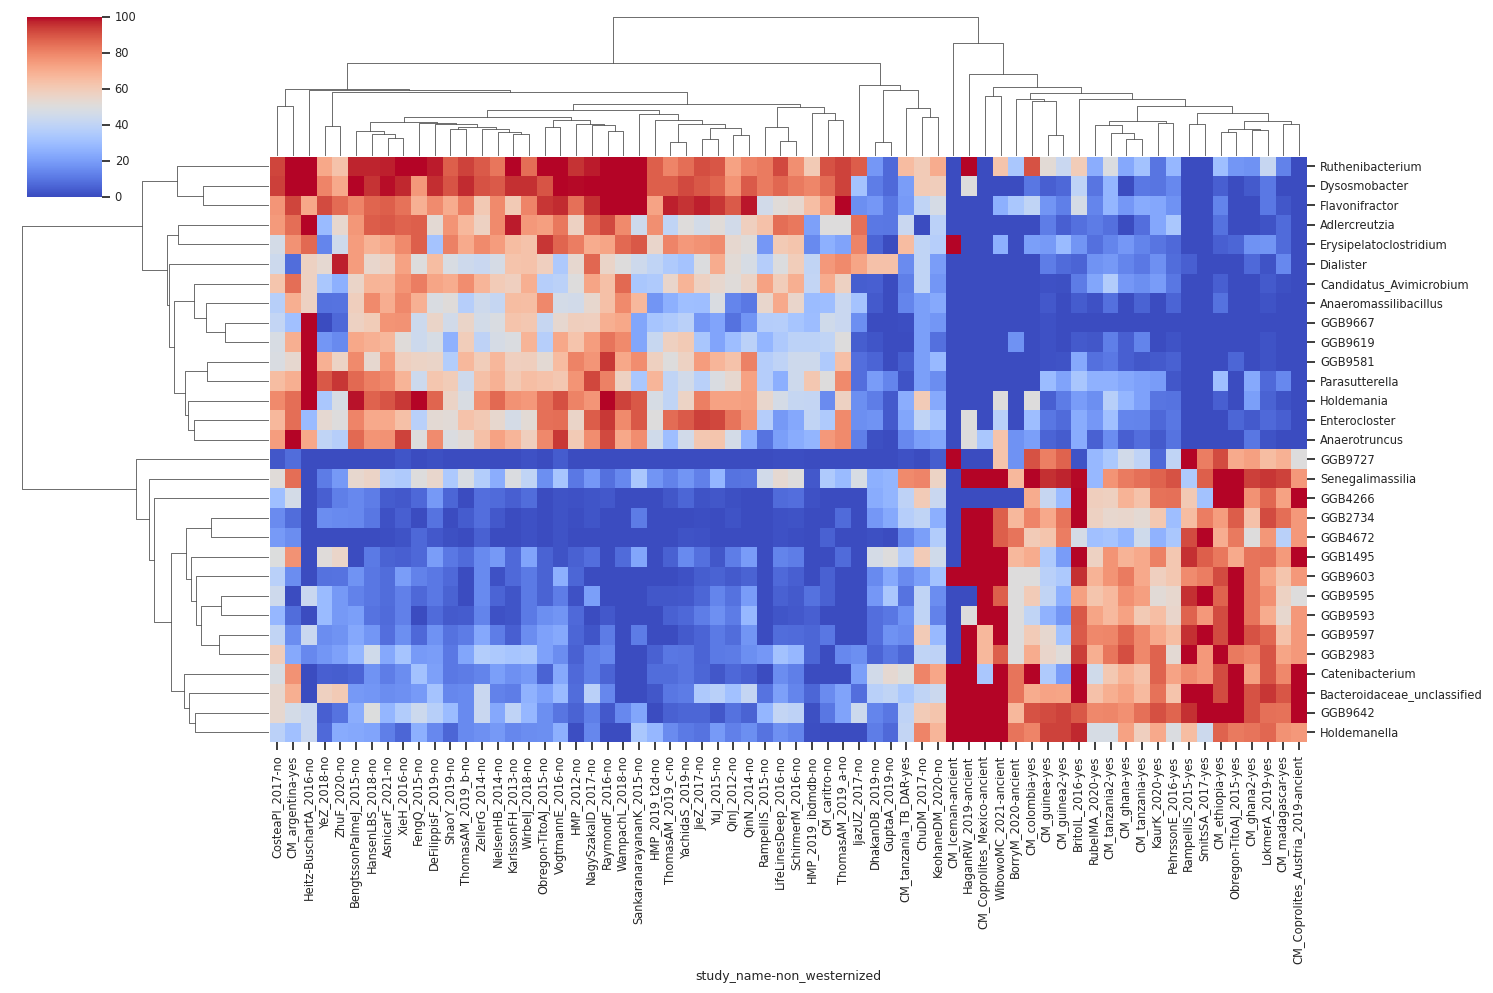

In [70]:
sns.set(font_scale=0.75)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
sns.clustermap(for_heatmap.transpose()[sample_selection], figsize=(15, 10), cmap='coolwarm')
plt.pyplot.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/clustered_heatmap.svg')

## Family level

In [327]:
keep = list()
for x in abundances.index.tolist():
    keep.append('f__' in x and 'g__' not in x)
family_abundances = abundances.loc[keep]
family_abundances.index = [x.split('|')[-1][3:].replace('_','') for x in family_abundances.index.tolist()]
family_abundances

,MMRS62666492ST-27-0-0,MMRS51737257ST-27-0-0,MMRS38861560ST-27-0-0,MMRS95674036ST-27-0-0,MMRS67096717ST-27-0-0,MMRS84085284ST-27-0-0,MMRS51307502ST-27-0-0,MMRS17963147ST-27-0-0,MMRS39582183ST-27-0-0,MMRS35808664ST-27-0-0,...,SID15785561_SF07,SID19401504_SF05,SID20269046_SF08,SID50492523_SF07,SID10502288_SF08,SID72242320_SF07,SID30920067_SF07,SID11486372_SF08,SID16913125_SF05,SID16853657_SF05
Ruminococcaceae,28.77187,15.77737,17.15878,6.45304,17.72565,16.10534,28.51597,24.29054,12.50235,8.79863,...,14.65847,15.72957,25.93056,18.92493,21.09630,20.17705,17.82874,14.35866,31.16491,20.92627
Lachnospiraceae,14.77119,25.64957,22.88997,10.53680,13.48796,10.06421,7.15188,13.56567,12.37591,12.61854,...,27.26430,27.14174,22.96807,27.31497,14.89155,24.34756,26.15344,37.19458,26.66251,20.08099
Prevotellaceae,11.54777,9.11350,0.00561,1.81475,0.00258,9.73808,0.00234,0.00102,6.51150,30.00061,...,0.00000,0.00000,1.66271,0.00000,0.68406,0.29666,24.82182,0.00000,0.00000,0.00000
Clostridiaunclassified,9.34144,6.80566,14.75664,0.06280,10.90183,3.65404,39.62869,2.64705,30.80175,1.91013,...,7.92744,1.99760,16.21617,1.00023,15.25007,12.17113,3.94818,5.04700,4.88363,5.49451
Bacteroidaceae,5.09787,11.90054,9.27670,27.98616,6.76791,14.77279,2.51068,13.58390,1.71145,6.54012,...,24.84529,18.59196,1.92787,14.09464,6.25618,6.72498,2.20520,6.47708,7.19272,15.95693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Pelagibacteraceae,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
Methanomicrobialesunclassified,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
FGB4685,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
Culicoidibacteraceae,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000


In [329]:
family_adults_abundances = family_abundances[adults_metadata['sample_id']]
family_adults_abundances = family_adults_abundances.drop(family_adults_abundances.loc[family_adults_abundances.sum(axis=1) == 0].index.tolist())
family_adults_abundances = family_adults_abundances.transpose()
family_adults_abundances = family_adults_abundances.drop(family_adults_abundances.loc[family_adults_abundances.sum(axis=1) == 0].index.tolist())
family_adults_abundances = family_adults_abundances.transpose()
family_adults_abundances

,O2_UC49_0,O2_UC49_2,O2_UC50_0,O2_UC50_2,O2_UC51_0,O2_UC51_2,O2_UC52_0,O2_UC53_0,O2_UC53_2,O2_UC54_0,...,AZ110A,Zape3,ERR3761413,ERR3761410,ERR3761412,SAMEA6415059,ERR3761407,ERR3761411,Zape5,Zape28
Ruminococcaceae,3.10174,12.48906,16.81951,17.78964,13.23127,14.58989,12.33587,14.96155,11.06258,11.03494,...,10.72235,38.51137,2.41759,17.13764,7.09964,23.97372,9.47112,8.77311,16.19571,16.05102
Lachnospiraceae,35.74193,15.59466,14.66110,16.96176,23.29857,25.04483,5.82241,30.20392,27.03053,17.58770,...,14.03493,16.36048,16.84053,12.74178,7.79050,7.17736,7.68022,12.24760,17.39775,18.42023
Prevotellaceae,9.09156,0.25326,4.38036,6.76708,0.59495,0.45123,3.17272,0.34050,1.12712,0.35179,...,14.61954,7.36616,48.55889,35.02930,3.38513,2.34148,0.00000,13.62715,1.52707,11.29147
Clostridiaunclassified,1.13130,7.17923,12.42606,6.25239,8.19686,13.54214,22.10849,3.03837,1.24090,9.46499,...,8.37477,18.68084,0.29972,0.26472,6.94964,39.66958,0.00000,10.57351,29.95938,20.64097
Bacteroidaceae,15.98495,17.67813,13.69035,10.09041,16.35998,12.38272,14.16702,3.89449,10.76603,9.83838,...,7.73997,0.37871,1.65690,0.17024,7.99073,0.25602,17.61855,1.71929,1.41609,1.06983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Microcoleaceae,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
Methanomicrobialesunclassified,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
FGB4685,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
Culicoidibacteraceae,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000


In [331]:
filtered_family_abundances = family_adults_abundances[filtered_adults_metadata.columns]
filtered_family_abundances

,O2_UC49_0,O2_UC49_2,O2_UC50_0,O2_UC50_2,O2_UC51_0,O2_UC51_2,O2_UC52_0,O2_UC53_0,O2_UC53_2,O2_UC54_0,...,C16-20615-TZ,C16-20616-TZ,C16-20617-TZ,C16-20625-TZ,C16-20626-TZ,C16-20627-TZ,C16-20645-TZ,C16-20646-TZ,C16-20647-TZ,C16-20664-TZ
Ruminococcaceae,3.10174,12.48906,16.81951,17.78964,13.23127,14.58989,12.33587,14.96155,11.06258,11.03494,...,17.41216,19.12782,12.68762,5.13627,5.83136,22.07460,11.91350,9.35656,10.55178,19.11697
Lachnospiraceae,35.74193,15.59466,14.66110,16.96176,23.29857,25.04483,5.82241,30.20392,27.03053,17.58770,...,9.69370,11.16766,17.30736,19.76939,10.02795,12.55100,9.88631,11.28892,7.44216,21.34203
Prevotellaceae,9.09156,0.25326,4.38036,6.76708,0.59495,0.45123,3.17272,0.34050,1.12712,0.35179,...,13.29822,14.71719,53.12070,41.50073,54.69066,16.47506,30.07650,44.39303,34.43188,18.71117
Clostridiaunclassified,1.13130,7.17923,12.42606,6.25239,8.19686,13.54214,22.10849,3.03837,1.24090,9.46499,...,13.30065,14.27255,0.97271,0.88475,1.62804,5.65878,5.19366,3.13598,6.28418,8.14251
Bacteroidaceae,15.98495,17.67813,13.69035,10.09041,16.35998,12.38272,14.16702,3.89449,10.76603,9.83838,...,5.28283,4.03797,2.79369,6.44652,3.59400,5.27464,2.97571,8.25901,1.91313,0.73696
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Microcoleaceae,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
Methanomicrobialesunclassified,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
FGB4685,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
Culicoidibacteraceae,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000


In [381]:
for species in ['Ruminococcaceae']:
    data_table = filtered_adults_metadata.append(filtered_family_abundances.loc[species].transpose()).transpose()
    data_table[species] = data_table[species].astype(bool).astype(int)
    w = data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'no'].index][species]
    nw = data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'yes'].index][species]
    if ((w.sum() / len(w) >= 0.1) or (nw.sum() / len(nw) >= 0.1)): #and not (w.sum() / len(w) >= 0.9) and (nw.sum() / len(nw) >= 0.9):    
        data_table['number_reads'] = data_table['number_reads'].astype(int)
        data_table['age'] = data_table['age'].astype(float)
        model = BinomialBayesMixedGLM.from_formula('{} ~ non_westernized + age + C(gender)'.format(species), {"study": '0 + C(study_name)'}, data_table,  vcp_p=.5)
        result = model.fit_map()
        S = result.summary()
        m = S.tables[0]["Post. Mean"]["non_westernized[T.yes]"]
        s = S.tables[0]["Post. SD"]["non_westernized[T.yes]"]
        z_value = m/s
        p_value = 2 * sts.norm.cdf(-np.abs(z_value))
        print('{} {} {} {} {}'.format(species, z_value, m, s, p_value))
        

Ruminococcaceae -1.6585239198173696 -1.0850625289494127 0.6542338738586874 0.09721176361660058


In [378]:
data_table

,study_name,age,gender,non_westernized,number_reads,Ruminococcaceae
O2_UC49_0,NielsenHB_2014,22.0,female,no,60584637,1
O2_UC49_2,NielsenHB_2014,22.0,female,no,56508214,1
O2_UC50_0,NielsenHB_2014,24.0,male,no,65105855,1
O2_UC50_2,NielsenHB_2014,24.0,male,no,53260679,1
O2_UC51_0,NielsenHB_2014,32.0,female,no,57486896,1
...,...,...,...,...,...,...
C16-20627-TZ,CM_tanzania,20.0,male,yes,38426298,1
C16-20645-TZ,CM_tanzania,34.0,female,yes,66130906,1
C16-20646-TZ,CM_tanzania,40.0,male,yes,66850184,1
C16-20647-TZ,CM_tanzania,18.0,female,yes,62136875,1


In [387]:
p_values = list()
results = dict()
for species in filtered_family_abundances.index.tolist():
    data_table = filtered_adults_metadata.append(filtered_family_abundances.loc[species].transpose()).transpose()
    data_table[species] = data_table[species].astype(bool).astype(int)
    w = data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'no'].index][species]
    nw = data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'yes'].index][species]
    if ((w.sum() / len(w) >= 0.1) or (nw.sum() / len(nw) >= 0.1)) and not ((w.sum() / len(w) >= 0.9) and (nw.sum() / len(nw) >= 0.9)):    
        data_table['number_reads'] = data_table['number_reads'].astype(int)
        data_table['age'] = data_table['age'].astype(float)
        model = BinomialBayesMixedGLM.from_formula('{} ~ non_westernized + age + C(gender)'.format(species), {"study": '0 + C(study_name)'}, data_table, vcp_p=.5)
        result = model.fit_map()
        S = result.summary()
        m = S.tables[0]["Post. Mean"]["non_westernized[T.yes]"]
        s = S.tables[0]["Post. SD"]["non_westernized[T.yes]"]
        z_value = m/s
        p_value = 2 * sts.norm.cdf(-np.abs(z_value))
        p_values.append(p_value)
        results[species] =  [z_value, p_value]
        print('{} {} {}'.format(species, z_value, p_value))

Prevotellaceae 6.679199613622015 2.4025073908989333e-11
Rikenellaceae -1.8460937407975746 0.06487859552958002
Bacteroidalesunclassified -5.4799162233243495 4.255272753385346e-08
Bacilliunclassified 8.673946293115772 4.173972384485999e-18
Veillonellaceae 1.0540501666115116 0.2918599497778004
Odoribacteraceae -6.048958314299916 1.4578537139307456e-09
Oscillospiraceae -2.4025514226755007 0.016281145313862978
FGB1340 5.679426393856027 1.3514719179038175e-08
Tannerellaceae -2.6135655936876083 0.008960288220335746
Peptostreptococcaceae -0.606880894714576 0.5439299579970205
FGB1798 2.330243318669797 0.01979329464857779
Acidaminococcaceae 2.7068728768134367 0.006792026001722128
Akkermansiaceae -6.693144999331546 2.1842451215975328e-11
Firmicutesunclassified 2.5459796109613047 0.010897155299994877
Sutterellaceae -5.176205213603953 2.2644438152482619e-07
Streptococcaceae -2.849458451502945 0.004379372529848486
FGB3035 -5.854215368681737 4.7926723459708265e-09
Barnesiellaceae -7.657884162706759 1

In [388]:
fdrs = statsmodels.stats.multitest.fdrcorrection(p_values)
lm_results = pd.DataFrame.from_dict(results).transpose()
lm_results.columns = ['z-score', 'p-value']
lm_results['q-value'] = fdrs[1]
lm_results.to_csv('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_bayesian_model_family.tsv',sep='\t')

In [394]:
# Mean by study
species2meandif = dict()
for species in lm_results.index.tolist():
    data_table = filtered_adults_metadata.append(filtered_family_abundances.loc[species].transpose()).transpose()
    data_table[species] = data_table[species].astype(bool).astype(int)
    w = statistics.mean((data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'no'].index].groupby('study_name')[species].sum() / data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'no'].index].groupby('study_name')[species].count() * 100).values)
    nw = statistics.mean((data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'yes'].index].groupby('study_name')[species].sum() / data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'yes'].index].groupby('study_name')[species].count() * 100).values)
    species2meandif[species] = w - nw
species2meandif = {k: v for k, v in sorted(species2meandif.items(), key=lambda item: item[1])}
species2meandif

{'FGB1062': -58.84589262558792,
 'FGB1218': -52.1874003526264,
 'Coriobacterialesunclassified': -47.595883657164926,
 'Phyllobacteriaceae': -47.55621768560499,
 'FGB16911': -45.09768567427776,
 'Pirellulaceae': -43.560903804258245,
 'FGB1298': -43.088858598617065,
 'CandidatusGastranaerophilalesunclassified': -39.37356836362273,
 'Selenomonadaceae': -38.249835742607786,
 'Elusimicrobialesunclassified': -37.87226058656138,
 'FGB11737': -36.47412154595243,
 'Spirochaetaceae': -36.35682794320134,
 'FGB544': -35.24136708777206,
 'Lentisphaeriaunclassified': -33.48440659729293,
 'Methanobacteriaceae': -33.01412012900828,
 'Atopobiaceae': -32.85500221974749,
 'ClostridialesFamilyXIIIIncertaeSedis': -32.68774462538037,
 'Bacilliunclassified': -31.004134618349894,
 'FGB2950': -29.71910500501505,
 'Oxalobacteraceae': -28.96186088066322,
 'Kiritimatiellaeunclassified': -28.52034175571611,
 'FGB4469': -28.323122731174745,
 'Spirochaetiaunclassified': -27.770594036768866,
 'Opitutalesunclassified'

In [395]:
nw = list(species2meandif.keys())[0:15]
species2meandif_r = {k: v for k, v in sorted(species2meandif.items(), reverse=True, key=lambda item: item[1])}
w = list(species2meandif_r.keys())[0:15]
enr_abundances = family_adults_abundances.loc[nw+w]
adults_prevs = enr_abundances.transpose().astype(bool).astype(int)
for_heatmap = (adults_metadata_heatmap[['study_name', 'non_westernized']].transpose().append(adults_prevs.transpose()).transpose().groupby(['study_name', 'non_westernized']).sum() / adults_metadata_heatmap[['study_name', 'non_westernized']].transpose().append(adults_prevs.transpose()).transpose().groupby(['study_name', 'non_westernized']).count()) * 100
sample_selection = [(x,y) for x,y in for_heatmap.transpose().columns if y=='no'] + [(x,y) for x,y in for_heatmap.transpose().columns if y=='yes'] + [(x,y) for x,y in for_heatmap.transpose().columns if y=='ancient']

In [392]:
w_enr = lm_results [lm_results['z-score'] < 0].sort_values('z-score').index.to_list()
nw_enr = lm_results [lm_results['z-score'] > 0].sort_values('z-score').index.to_list()
w_enr = lm_results.sort_values('z-score').iloc[0:15].index.to_list()
nw_enr = lm_results.sort_values('z-score', ascending=False).iloc[0:15].index.to_list()
enr_abundances = family_adults_abundances.loc[w_enr + nw_enr]
adults_prevs = enr_abundances.transpose().astype(bool).astype(int)
for_heatmap = (filtered_adults_metadata.transpose()[['study_name', 'non_westernized']].transpose().append(adults_prevs.transpose()).transpose().groupby(['study_name', 'non_westernized']).sum() / filtered_adults_metadata.transpose()[['study_name', 'non_westernized']].transpose().append(adults_prevs.transpose()).transpose().groupby(['study_name', 'non_westernized']).count()) * 100
sample_selection = [(x,y) for x,y in for_heatmap.transpose().columns if y=='no'] + [(x,y) for x,y in for_heatmap.transpose().columns if y=='yes']

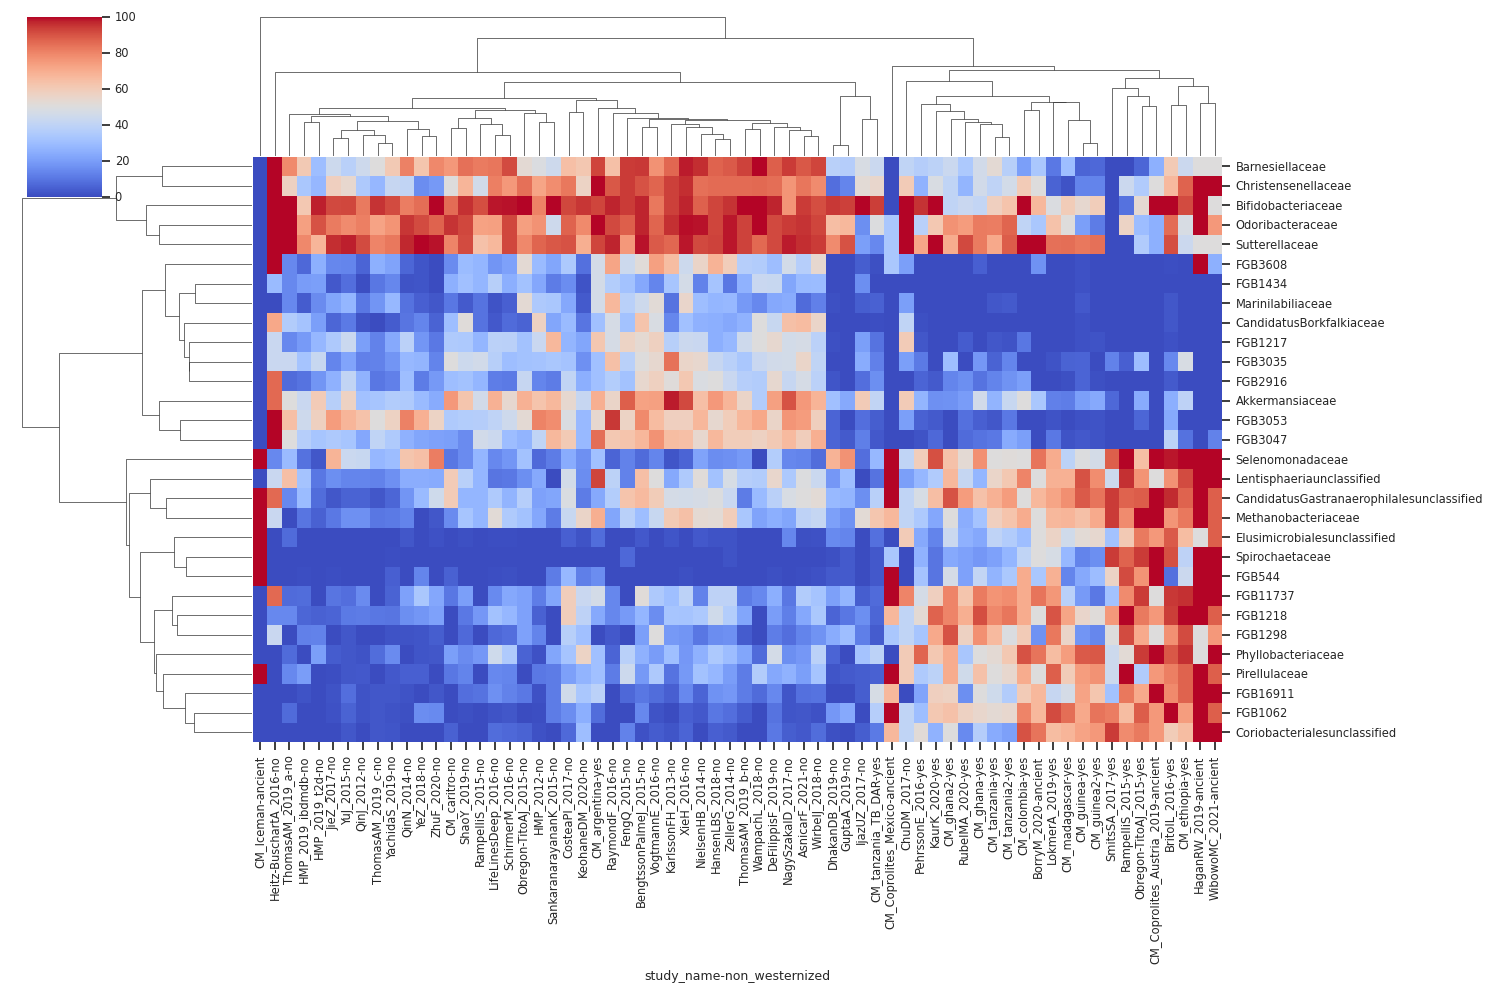

In [396]:
sns.set(font_scale=0.75)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
sns.clustermap(for_heatmap.transpose()[sample_selection], figsize=(15, 10), cmap='coolwarm')
plt.pyplot.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/clustered_heatmap.svg')

In [402]:
family_enr = pd.read_table('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_bayesian_model_family.tsv', index_col=[0], sep='\t')
genus_enr = pd.read_table('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_bayesian_model_genus.tsv', index_col=[0], sep='\t')

In [1405]:
family_enr.index.tolist()

['Prevotellaceae',
 'Rikenellaceae',
 'Bacteroidalesunclassified',
 'Bacilliunclassified',
 'Veillonellaceae',
 'Odoribacteraceae',
 'Oscillospiraceae',
 'FGB1340',
 'Tannerellaceae',
 'Peptostreptococcaceae',
 'FGB1798',
 'Acidaminococcaceae',
 'Akkermansiaceae',
 'Firmicutesunclassified',
 'Sutterellaceae',
 'Streptococcaceae',
 'FGB3035',
 'Barnesiellaceae',
 'Coriobacteriaceae',
 'Pasteurellaceae',
 'Desulfovibrionaceae',
 'Bifidobacteriaceae',
 'Enterobacteriaceae',
 'Methanobacteriaceae',
 'Acholeplasmatalesunclassified',
 'Lentisphaeriaunclassified',
 'FGB2916',
 'FGB11371',
 'FGB1298',
 'FGB11737',
 'Enterococcaceae',
 'Christensenellaceae',
 'Atopobiaceae',
 'FGB3048',
 'FGB42691',
 'FGB3047',
 'FGB16911',
 'CandidatusBorkfalkiaceae',
 'FGB1217',
 'Victivallaceae',
 'FGB24517',
 'FGB12277',
 'FGB3608',
 'FGB9370',
 'Promicromonosporaceae',
 'ClostridialesFamilyXIIIIncertaeSedis',
 'Actinomycetaceae',
 'Synergistaceae',
 'Methanomassiliicoccalesunclassified',
 'Flavobacteriales

In [425]:
families = dict()
orders = dict()
with bz2.open('/shares/CIBIO-Storage/CM/scratch/databases/MetaRefSGB/releases/Jan21/SGB.Jan21.txt.bz2', 'rt') as  rf:
    for line in rf:
        if line.startswith('SGB'):
            line = line.strip().split('\t')
            if line[9].split('|')[-4][3:] not in families:
                families[line[9].split('|')[-4][3:]] = set()
            families[line[9].split('|')[-4][3:]].add(line[9].split('|')[-3][3:])
            if line[9].split('|')[-5][3:] not in orders:
                orders[line[9].split('|')[-5][3:]] = set()
            orders[line[9].split('|')[-5][3:]].add(line[9].split('|')[-4][3:])
        elif line.startswith('GGB'):
            break

In [1402]:
orders['Bacteroidales']

{'Bacteroidaceae',
 'Bacteroidales_unclassified',
 'Balneicellaceae',
 'Barnesiellaceae',
 'Dysgonomonadaceae',
 'Lentimicrobiaceae',
 'Muribaculaceae',
 'Odoribacteraceae',
 'Paludibacteraceae',
 'Porphyromonadaceae',
 'Prevotellaceae',
 'Rikenellaceae',
 'Tannerellaceae',
 'Tenuifilaceae',
 'Williamwhitmaniaceae'}

In [429]:
family_difs = dict()
for family in families:    
    for genus in families[family]:
        if genus.replace('_','') in genus_enr.index.tolist():
            if family not in family_difs:
                family_difs[family] = {'w':[], 'nw': [], 'ns':[]}
            if genus_enr.loc[genus.replace('_',''), 'q-value'] < 0.01:
                if genus_enr.loc[genus.replace('_',''), 'z-score'] > 0:
                    family_difs[family]['nw'].append(genus + ' ' + str(genus_enr.loc[genus.replace('_',''), 'z-score']))
                else:
                    family_difs[family]['w'].append(genus + ' ' + str(genus_enr.loc[genus.replace('_',''), 'z-score']))
                
            else:
                family_difs[family]['ns'].append(genus + ' ' + str(genus_enr.loc[genus.replace('_',''), 'z-score']))
                

In [1398]:
family_with_two = {k:v for k,v in family_difs.items() if len(v['w']) > 0 and len(v['nw']) > 0}
family_with_two

{'Clostridia_unclassified': {'w': ['GGB9537 -4.080671878426217',
   'GGB2980 -6.6422041932921125',
   'Candidatus_Metaruminococcus -7.647585264723226',
   'Candidatus_Schneewindia -7.21128312327113',
   'Candidatus_Allobutyricicoccus -6.238752682047147',
   'GGB4596 -9.209420716164946',
   'Candidatus_Pararuminococcus -7.547200341747968',
   'Candidatus_Aristotella -5.138499638564234',
   'GGB4588 -4.322697348009242',
   'GGB4566 -6.215952085409489',
   'Candidatus_Heteroscilispira -5.559356051292216',
   'GGB3005 -8.100785581084745',
   'Candidatus_Pseudoruminococcus -7.104428921330423',
   'GGB9494 -7.00975307958491',
   'Candidatus_Geddesella -6.156967775912567',
   'Candidatus_Allochristensenella -5.067031314908103',
   'Candidatus_Avimicrobium -8.768399068431426',
   'Candidatus_Alloruminococcus -3.994497387368228',
   'GGB9176 -6.072884811960271',
   'Candidatus_Pseudobutyricicoccus -7.455542130172229',
   'GGB9350 -5.84330638693564',
   'Candidatus_Neoruminococcus -6.43945425305

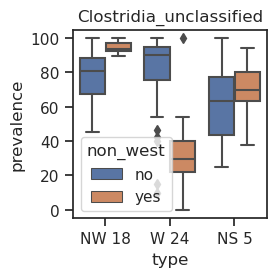

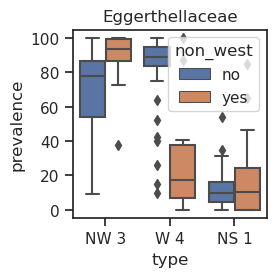

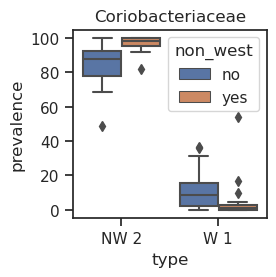

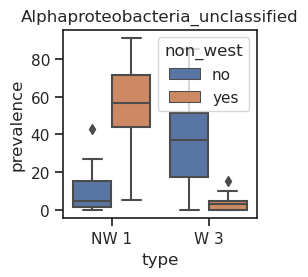

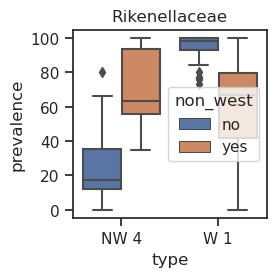

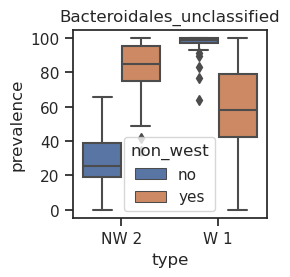

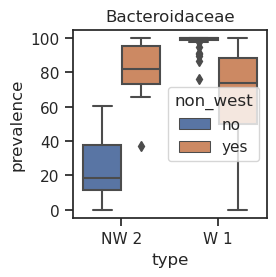

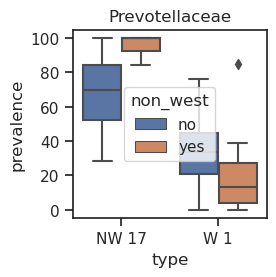

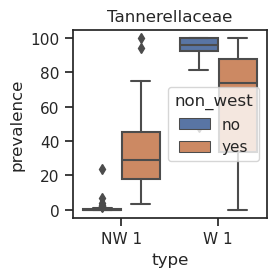

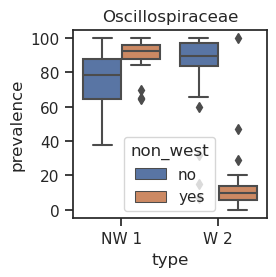

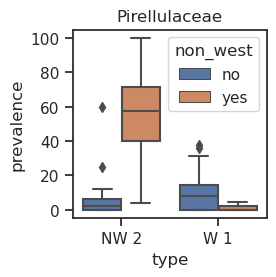

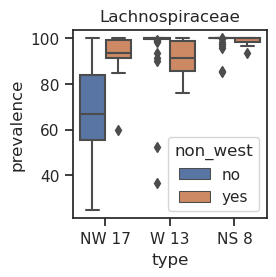

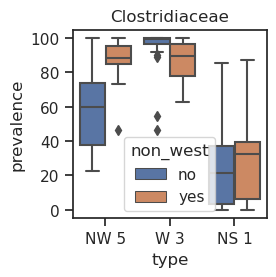

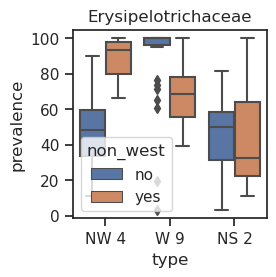

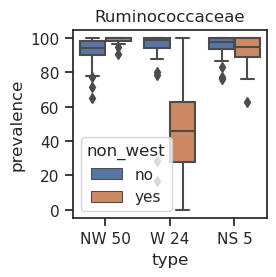

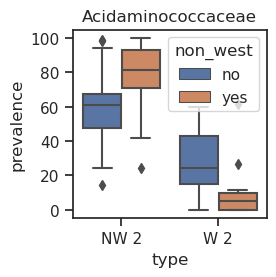

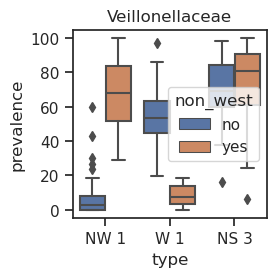

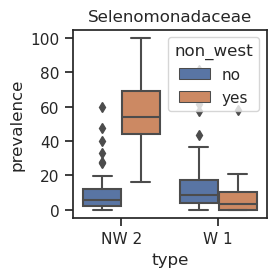

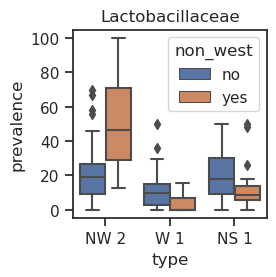

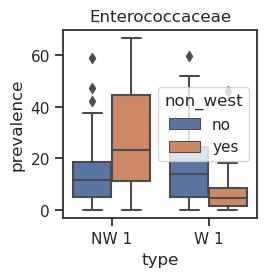

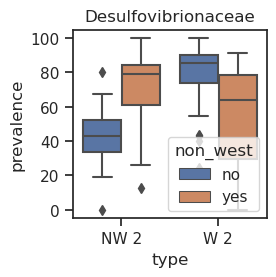

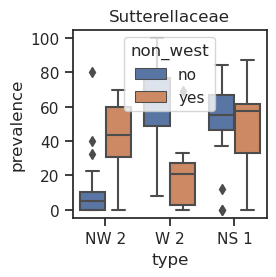

In [1399]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [2.5,2.5]
i = 0
for family in family_with_two:
    i += 1
    plt.pyplot.figure(i)
    w = [x.split(' ')[0].replace('_','') for x in family_with_two[family]['w']]
    nw = [x.split(' ')[0].replace('_','') for x in family_with_two[family]['nw']]
    ns = [x.split(' ')[0].replace('_','') for x in family_with_two[family]['ns']]
#     print(w)
#     print(nw)
#     print(ns)
    w_prevs = genus_adults_abundances.loc[w].sum().astype(bool).astype(int)
    w_prevs_meta = adults_metadata_heatmap[['study_name', 'non_westernized']].transpose().append(w_prevs,ignore_index=True).transpose()
    w_prevs_meta.columns = ['study_name', 'non_westernized', 'prevalence']
    w_prevs_meta=w_prevs_meta.groupby(['study_name', 'non_westernized']).mean()
    w_prevs_meta['type'] = 'W {}'.format(len(w))   
    nw_prevs = genus_adults_abundances.loc[nw].sum().astype(bool).astype(int)
    nw_prevs_meta = adults_metadata_heatmap[['study_name', 'non_westernized']].transpose().append(nw_prevs,ignore_index=True).transpose()
    nw_prevs_meta.columns = ['study_name', 'non_westernized', 'prevalence']
    nw_prevs_meta=nw_prevs_meta.groupby(['study_name', 'non_westernized']).mean()
    nw_prevs_meta['type'] = 'NW {}'.format(len(nw))
    if len(ns) > 0:
        ns_prevs = genus_adults_abundances.loc[ns].sum().astype(bool).astype(int)
        ns_prevs_meta = adults_metadata_heatmap[['study_name', 'non_westernized']].transpose().append(ns_prevs,ignore_index=True).transpose()
        ns_prevs_meta.columns = ['study_name', 'non_westernized', 'prevalence']
        ns_prevs_meta=ns_prevs_meta.groupby(['study_name', 'non_westernized']).mean()
        ns_prevs_meta['type'] = 'NS {}'.format(len(ns))
    for_boxplot = nw_prevs_meta.append(w_prevs_meta)
    if len(ns) > 0:
        for_boxplot = for_boxplot.append(ns_prevs_meta)
    for_boxplot['non_west'] = [x[1] for x in for_boxplot.index]
    for_boxplot = for_boxplot[for_boxplot['non_west'] != 'ancient']
    for_boxplot['prevalence'] = for_boxplot['prevalence'] * 100
    g = sns.boxplot(data = for_boxplot, x='type', y='prevalence', hue='non_west').set(title=family)

In [1378]:
order_difs = dict()
for order in orders:    
    for family in orders[order]:
        if family.replace('_','') in family_enr.index.tolist():
            if order not in order_difs:
                order_difs[order] = {'w':[], 'nw': [], 'ns':[]}
            if family_enr.loc[family.replace('_',''), 'q-value'] < 0.01:
                if family_enr.loc[family.replace('_',''), 'z-score'] > 0:
                    order_difs[order]['nw'].append(family + ' ' + str(family_enr.loc[family.replace('_',''), 'z-score']))
                else:
                    order_difs[order]['w'].append(family + ' ' + str(family_enr.loc[family.replace('_',''), 'z-score']))
            else:
                order_difs[order]['ns'].append(family + ' ' + str(family_enr.loc[family.replace('_',''), 'z-score']))
                

In [1400]:
order_with_two = {k:v for k,v in order_difs.items() if len(v['w']) > 0 and len(v['nw']) > 0}
order_with_two

{'Clostridiales': {'w': ['Christensenellaceae -4.11831889301909',
   'Catabacteriaceae -5.792173378024104'],
  'nw': ['Clostridiales_Family_XIII_Incertae_Sedis 6.369033331634796',
   'Peptococcaceae 6.516712651881059'],
  'ns': ['Oscillospiraceae -2.4025514226755007',
   'Peptostreptococcaceae -0.606880894714576']},
 'Bacteroidales': {'w': ['Bacteroidales_unclassified -5.4799162233243495',
   'Odoribacteraceae -6.048958314299916',
   'Barnesiellaceae -7.657884162706759'],
  'nw': ['Prevotellaceae 6.679199613622015'],
  'ns': ['Porphyromonadaceae -2.233777298047848',
   'Tannerellaceae -2.6135655936876083',
   'Rikenellaceae -1.8460937407975744']},
 'Lactobacillales': {'w': ['Streptococcaceae -2.849458451502945'],
  'nw': ['Leuconostocaceae 5.7528367856404525'],
  'ns': ['Enterococcaceae 1.2235562263024844',
   'Lactobacillaceae 2.5962444171028105']},
 'Burkholderiales': {'w': ['Sutterellaceae -5.176205213603953'],
  'nw': ['Oxalobacteraceae 6.6975641551515',
   'Comamonadaceae 7.580617

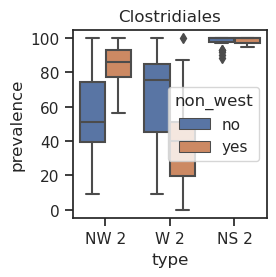

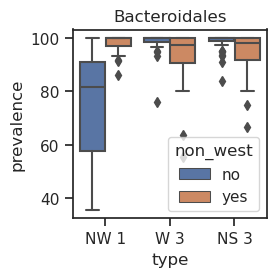

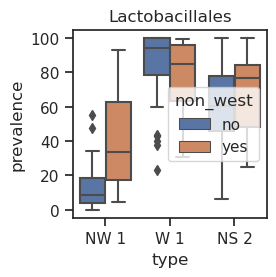

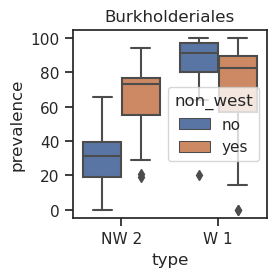

In [1401]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [2.5,2.5]
i = 0
for family in order_with_two:
    i += 1
    plt.pyplot.figure(i)
    w = [x.split(' ')[0].replace('_','') for x in order_with_two[family]['w']]
    nw = [x.split(' ')[0].replace('_','') for x in order_with_two[family]['nw']]
    ns = [x.split(' ')[0].replace('_','') for x in order_with_two[family]['ns']]
#     print(w)
#     print(nw)
#     print(ns)
    w_prevs = family_adults_abundances.loc[w].sum().astype(bool).astype(int)
    w_prevs_meta = adults_metadata_heatmap[['study_name', 'non_westernized']].transpose().append(w_prevs,ignore_index=True).transpose()
    w_prevs_meta.columns = ['study_name', 'non_westernized', 'prevalence']
    w_prevs_meta=w_prevs_meta.groupby(['study_name', 'non_westernized']).mean()
    w_prevs_meta['type'] = 'W {}'.format(len(w))   
    nw_prevs = family_adults_abundances.loc[nw].sum().astype(bool).astype(int)
    nw_prevs_meta = adults_metadata_heatmap[['study_name', 'non_westernized']].transpose().append(nw_prevs,ignore_index=True).transpose()
    nw_prevs_meta.columns = ['study_name', 'non_westernized', 'prevalence']
    nw_prevs_meta=nw_prevs_meta.groupby(['study_name', 'non_westernized']).mean()
    nw_prevs_meta['type'] = 'NW {}'.format(len(nw))
    if len(ns) > 0:
        ns_prevs = family_adults_abundances.loc[ns].sum().astype(bool).astype(int)
        ns_prevs_meta = adults_metadata_heatmap[['study_name', 'non_westernized']].transpose().append(ns_prevs,ignore_index=True).transpose()
        ns_prevs_meta.columns = ['study_name', 'non_westernized', 'prevalence']
        ns_prevs_meta=ns_prevs_meta.groupby(['study_name', 'non_westernized']).mean()
        ns_prevs_meta['type'] = 'NS {}'.format(len(ns))
    for_boxplot = nw_prevs_meta.append(w_prevs_meta)
    if len(ns) > 0:
        for_boxplot = for_boxplot.append(ns_prevs_meta)
    for_boxplot['non_west'] = [x[1] for x in for_boxplot.index]
    for_boxplot = for_boxplot[for_boxplot['non_west'] != 'ancient']
    for_boxplot['prevalence'] = for_boxplot['prevalence'] * 100
    g = sns.boxplot(data = for_boxplot, x='type', y='prevalence', hue='non_west').set(title=family)

## Michal results

In [480]:
df = pd.read_table('/shares/CIBIO-Storage/CM/scratch/users/michal.puncochar/nw_analysis/output_table_fix.tsv', index_col=[0], sep='\t')
df

,k,cluster_sizes,all_purities,min_purity,major_labels,min_purity_china,major_labels_china,all_purities_china,tax
sgb,,,,,,,,,
SGB4705,7,[998 296 62 398 45 56 110],[0.91482966 1. 1. 0.92964824 0...,0.914830,['no' 'no' 'no' 'no' 'no' 'no' 'no'],0.548387,['no' 'no' 'yes' 'no' 'no' 'yes' 'no'],[0.8757515 1. 0.5483871 0.55527638 0...,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...
SGB12676,7,[12 6 11 8 15 33 20],[0.83333333 1. 1. 0.75 1...,0.696970,['yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes'],0.750000,['yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes'],[0.83333333 1. 1. 0.75 1...,k__Bacteria|p__Proteobacteria|c__Betaproteobac...
SGB17153_group,2,[103 74],[0.94174757 0.95945946],0.941748,['yes' 'yes'],0.941748,['yes' 'yes'],[0.94174757 0.95945946],k__Bacteria|p__Actinobacteria|c__Actinobacteri...
SGB15238,10,[ 24 14 104 45 19 12 18 28 25 20],[1. 0.64285714 0.51923077 0.66666667 0...,0.500000,['no' 'no' 'no' 'no' 'no' 'yes' 'no' 'no' 'no'...,0.500000,['no' 'yes' 'yes' 'no' 'yes' 'yes' 'no' 'no' '...,[1. 0.5 0.50961538 0.66666667 0...,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...
SGB9340,2,[647 9],[0.99690881 1. ],0.996909,['no' 'no'],0.962906,['no' 'no'],[0.96290572 1. ],k__Bacteria|p__Proteobacteria|c__Alphaproteoba...
...,...,...,...,...,...,...,...,...,...
SGB15107,10,[ 51 35 157 54 82 43 98 46 33 29],[0.88235294 0.88571429 0.96815287 0.64814815 1...,0.530612,['no' 'no' 'no' 'no' 'no' 'no' 'no' 'no' 'no' ...,0.520408,['no' 'no' 'no' 'no' 'no' 'no' 'no' 'no' 'no' ...,[0.70588235 0.88571429 0.96815287 0.64814815 1...,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...
SGB4575,2,[2209 190],[0.82933454 0.77894737],0.778947,['no' 'no'],0.721053,['no' 'no'],[0.80217293 0.72105263],k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...
SGB4829,2,[514 461],[0.98249027 0.85466377],0.854664,['no' 'no'],0.854664,['no' 'no'],[0.97470817 0.85466377],k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...


In [1540]:
#Prevalence
df_sel = df[((df.major_labels.map(lambda x: 'yes' in x and 'no' in x))) | ((df.major_labels_china.map(lambda x: 'yes' in x and 'no' in x)))].copy()
species2prev = dict()
for species in df_sel.tax.tolist():
    species = species.split('|')[-2][3:] + '___' + species.split('|')[-1][3:]
    data_table = filtered_adults_metadata.append(filtered_adults_abundances.loc[species].transpose()).transpose()
    data_table[species] = data_table[species].astype(bool).astype(int)
    w = statistics.mean((data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'no'].index].groupby('study_name')[species].sum() / data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'no'].index].groupby('study_name')[species].count() * 100).values)
    nw = statistics.mean((data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'yes'].index].groupby('study_name')[species].sum() / data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'yes'].index].groupby('study_name')[species].count() * 100).values)
    ov = statistics.mean((data_table.loc[filtered_adults_metadata.transpose().index].groupby('study_name')[species].sum() / data_table.loc[filtered_adults_metadata.transpose().index].groupby('study_name')[species].count() * 100).values)
    species2prev[species.split('___')[-1]] = [ov,statistics.mean([w,nw]), w/nw, w,nw, min(w,nw), max(w,nw)]
df_prev = pd.DataFrame.from_dict(species2prev).transpose()
df_prev.columns = ['Prevalence', 'Avg_Prevalence', 'Ratio', 'Westernized', 'Non-Westernized','min','max']

In [1300]:
#Relab
df_sel = df[((df.major_labels.map(lambda x: 'yes' in x and 'no' in x))) | ((df.major_labels_china.map(lambda x: 'yes' in x and 'no' in x)))].copy()
species2prev = dict()
for species in df_sel.tax.tolist():
    species = species.split('|')[-2][3:] + '___' + species.split('|')[-1][3:]
    data_table = filtered_adults_metadata.append(filtered_adults_abundances.loc[species].transpose()).transpose()
    data_table[species] = data_table[species]#.astype(bool).astype(int)
    w = statistics.mean(data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'no'].index].groupby('study_name')[species].mean())
    nw = statistics.mean(data_table.loc[filtered_adults_metadata.transpose()[filtered_adults_metadata.transpose()['non_westernized'] == 'yes'].index].groupby('study_name')[species].mean())
    ov = statistics.mean(data_table.loc[filtered_adults_metadata.transpose().index].groupby('study_name')[species].mean())
    species2prev[species.split('___')[-1]] = [math.log10(ov),math.log10(statistics.mean([w,nw])), math.log10(w),math.log10(nw), math.log10(min(w,nw)), math.log10((max(w,nw)))]
df_prev = pd.DataFrame.from_dict(species2prev).transpose()
df_prev.columns = ['Abundance', 'Avg_Abundance','Westernized', 'Non-Westernized','min','max']

In [ ]:
#Relab  non-zero
df_sel = df[((df.major_labels.map(lambda x: 'yes' in x and 'no' in x))) | ((df.major_labels_china.map(lambda x: 'yes' in x and 'no' in x)))].copy()
species2prev = dict()
for species in df_sel.tax.tolist():
    species = species.split('|')[-2][3:] + '___' + species.split('|')[-1][3:]
    data_table = filtered_adults_metadata.append(filtered_adults_abundances.loc[species].transpose()).transpose()
    data_table[species] = data_table[species]#.astype(bool).astype(int)
    w = statistics.mean(data_table.loc[filtered_adults_metadata.transpose()[(filtered_adults_metadata.transpose()['non_westernized'] == 'no') & (data_table.loc[filtered_adults_metadata.transpose().index][species] > 0)].index].groupby('study_name')[species].mean())
    nw = statistics.mean(data_table.loc[filtered_adults_metadata.transpose()[(filtered_adults_metadata.transpose()['non_westernized'] == 'yes') & (data_table.loc[filtered_adults_metadata.transpose().index][species] > 0)].index].groupby('study_name')[species].mean())
    ov = statistics.mean(data_table.loc[filtered_adults_metadata.transpose().index][data_table.loc[filtered_adults_metadata.transpose().index][species] > 0].groupby('study_name')[species].mean())
    species2prev[species.split('___')[-1]] = [math.log10(ov),math.log10(statistics.mean([w,nw])), math.log10(w),math.log10(nw), math.log10(min(w,nw)), math.log10((max(w,nw)))]
df_prev = pd.DataFrame.from_dict(species2prev).transpose()
df_prev.columns = ['Abundance', 'Avg_Abundance','Westernized', 'Non-Westernized','min','max']

In [1541]:
sgb2score = dict()
for index in df_sel.index:
    sizes = [int(x) for x in df_sel.loc[index,'cluster_sizes'][1:-1].split(' ') if x != '']
    if df_sel.loc[index,'min_purity'] >=  df_sel.loc[index,'min_purity_china']:
        scores = [float(x) for x in df_sel.loc[index,'all_purities'][1:-1].split(' ') if x != '']        
        labels = [str(x.replace("'", "")) for x in df_sel.loc[index,'major_labels'][1:-1].split(' ') if x != '']
    else:        
        scores = [float(x) for x in df_sel.loc[index,'all_purities_china'][1:-1].split(' ') if x != '']  
        labels = [str(x.replace("'", "")) for x in df_sel.loc[index,'major_labels_china'][1:-1].split(' ') if x != '']
    yes = []
    no = []
    scores_y = []
    scores_n = []
    for idx, x in enumerate(labels):
        if x == 'yes':
            yes.append(sizes[idx])
        if x == 'no':
            no.append(sizes[idx])        
    for idx, x in enumerate(labels):
        if x == 'yes':
            scores_y.append(scores[idx] * (sizes[idx]/ max(1, sum(yes))))
        if x == 'no':
            scores_n.append(scores[idx] * (sizes[idx] / max(1, sum(no))))
    if len(scores_y) > 0 and len(scores_n) > 0: # and sum(yes) > 20 and sum(no) > 200:
        mean_g_n = statistics.mean([sum(scores_y), sum(scores_n)])   
        sgb2score[index] = [mean_g_n, statistics.median(scores), statistics.mean(scores), df_sel.loc[index,'k'], sum(yes),sum(no), df_sel.loc[index,'tax'].split('|')[-4][3:], min(sum(no),sum(yes)), len([x for x in labels if x == 'yes']), min(scores), df_sel.loc[index,'tax']]
df_score = pd.DataFrame.from_dict(sgb2score, orient='index')
df_score.columns=['mean_g_n','median','mean','k','yes','no' ,'family', 'min_size', 'labels','min_score', 'tax']
df_final = df_score.join(df_prev.loc[df_score.index])
df_final

,mean_g_n,median,mean,k,yes,no,family,min_size,labels,min_score,tax,Prevalence,Avg_Prevalence,Ratio,Westernized,Non-Westernized,min,max
SGB15238,0.591751,0.690476,0.727088,10,12,297,Ruminococcaceae,12,1,0.500000,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,34.247539,41.681015,0.352514,21.727150,61.634880,21.727150,61.634880
SGB4571,0.826420,0.826420,0.826420,2,11,320,Lachnospiraceae,11,1,0.743750,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,53.018002,54.786913,0.819182,49.341350,60.232476,49.341350,60.232476
SGB2071,0.750075,0.750075,0.750075,2,283,824,Bacteroidales_unclassified,283,1,0.705097,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...,33.118801,42.874489,0.223736,15.677507,70.071470,15.677507,70.071470
SGB6178,0.852273,0.852273,0.852273,2,38,308,Clostridiaceae,38,1,0.704545,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,23.411827,23.564216,0.853529,21.702112,25.426321,21.702112,25.426321
SGB2238,0.809503,0.906040,0.870489,3,162,129,Rikenellaceae,129,2,0.705426,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...,14.281104,22.056223,0.047954,2.018557,42.093890,2.018557,42.093890
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SGB15019,0.922650,0.922222,0.885762,3,90,169,Ruminococcaceae,90,1,0.800000,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,25.344260,34.033764,0.192273,10.976951,57.090577,10.976951,57.090577
SGB5090_group,0.737105,0.737105,0.737105,2,202,2685,Clostridiales_unclassified,202,1,0.529703,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,82.068951,84.439757,0.870447,78.591198,90.288316,78.591198,90.288316
SGB7061,0.847074,0.895455,0.897124,3,226,343,Lactobacillaceae,226,2,0.795918,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactob...,19.899958,25.205165,0.268924,10.683505,39.726825,10.683505,39.726825
SGB14773_group,0.828534,0.828534,0.828534,2,231,382,Eggerthellaceae,231,1,0.657068,k__Bacteria|p__Actinobacteria|c__Coriobacterii...,42.258428,51.546988,0.334964,25.867964,77.226013,25.867964,77.226013


(0.3800283730833018, 3.3514536825433025e-06)

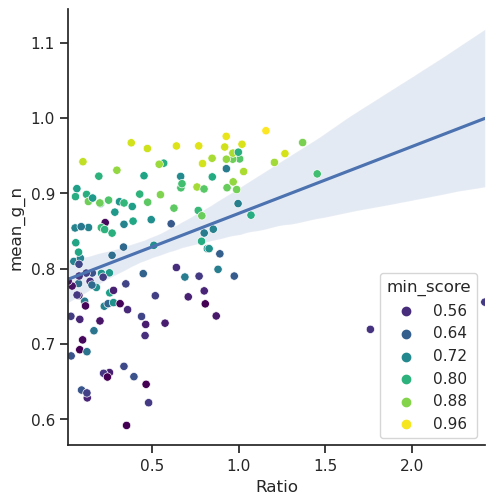

In [1542]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [5,5]
sns.lmplot(data=df_final, y='mean_g_n', x='Ratio', scatter=False)
sns.scatterplot(data=df_final, y='mean_g_n', x='Ratio', hue='min_score', palette='viridis', legend=True)
stats.pearsonr(df_final['mean_g_n'], df_final['Ratio'])

(0.4423494079986896, 3.9773631249157125e-08)


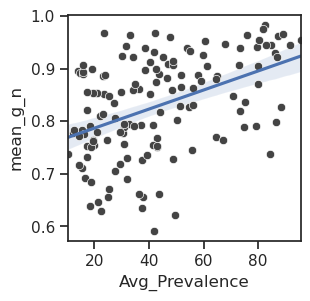

In [1534]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [3,3]
sns.regplot(data=df_final, y='mean_g_n', x='Avg_Prevalence', scatter=False)
sns.scatterplot(data=df_final, y='mean_g_n', x='Avg_Prevalence', color='#444444', legend=False)
print(stats.pearsonr(df_final['mean_g_n'], df_final['Avg_Prevalence']))
plt.pyplot.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/cluster_prev_corr.svg')

In [1124]:
enriched_sgbs = df_final[(df_final.min_score > 0.75) & (df_final.no > 200) & (df_final.yes > 20)]

In [1125]:
enriched_sgbs[enriched_sgbs.family=='Lachnospiraceae'].sort_values('min_score')

,mean_g_n,median,mean,k,yes,no,family,min_size,labels,min_score,tax,Prevalence,Avg_Prevalence,Westernized,Non-Westernized,min,max
SGB4563_group,0.921685,0.852174,0.879046,3,103,4367,Lachnospiraceae,103,1,0.784965,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,84.284883,87.021618,79.848304,94.194932,79.848304,94.194932
SGB4582_group,0.836271,0.836271,0.836271,2,438,1355,Lachnospiraceae,438,1,0.787671,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,72.778236,75.225567,66.194075,84.257059,66.194075,84.257059
SGB4925,0.870914,0.870914,0.870914,2,882,4337,Lachnospiraceae,882,1,0.790249,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,80.938533,80.110134,82.868202,77.352066,77.352066,82.868202
SGB5082_group,0.954512,0.978793,0.932949,5,112,4278,Lachnospiraceae,112,1,0.794643,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,80.729172,80.453271,80.385381,80.521160,80.385381,80.521160
SGB4809,0.912668,0.912668,0.912668,2,51,521,Lachnospiraceae,51,1,0.825336,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,37.400078,40.280799,32.396747,48.164850,32.396747,48.164850
SGB4933_group,0.945561,0.984855,0.942335,3,73,7311,Lachnospiraceae,73,1,0.842149,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,91.545764,91.528926,91.792879,91.264974,91.264974,91.792879
SGB4831_group,0.880229,0.893204,0.914609,3,122,482,Lachnospiraceae,122,2,0.850622,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,59.116020,64.734423,49.857618,79.611228,49.857618,79.611228
SGB4910,0.907347,0.968750,0.952124,5,420,2078,Lachnospiraceae,420,2,0.857143,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,72.045014,72.871851,70.344081,75.399622,70.344081,75.399622
SGB4811_group,0.945225,0.952218,0.938364,3,25,2848,Lachnospiraceae,25,1,0.862875,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,83.847762,84.570817,83.090295,86.051339,83.090295,86.051339
SGB5066,0.887123,0.896552,0.919969,3,101,322,Lachnospiraceae,101,2,0.863354,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...,18.306420,23.924993,7.913622,39.936365,7.913622,39.936365


In [1414]:
enriched_sgbs.to_csv('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_enriched_clusterwnw.tsv', sep='\t')

In [1126]:
family2number = pd.DataFrame.from_dict({family[3:]:len([x for x in [x.split('|')[-4] for x in df.tax] if x == family]) for family in set([x.split('|')[-4] for x in df.tax])}, orient='index')
family2number.columns = ['sgb_number']
family2number_enr = pd.DataFrame.from_dict({family[3:]:len([x for x in [x.split('|')[-4] for x in enriched_sgbs.tax] if x == family]) for family in set([x.split('|')[-4] for x in enriched_sgbs.tax])}, orient='index')
family2number_enr.columns = ['sgb_number_enr']
family2number = family2number.join(family2number_enr).fillna(0)
family2number[family2number.sgb_number_enr > 0]

,sgb_number,sgb_number_enr
Peptostreptococcaceae,4,1.0
Phyllobacteriaceae,1,1.0
Clostridiaceae,16,4.0
Ruminococcaceae,65,8.0
Clostridia_unclassified,30,2.0
Firmicutes_unclassified,1,1.0
Erysipelotrichaceae,7,2.0
Eubacteriaceae,5,1.0
Rikenellaceae,14,1.0
Lachnospiraceae,64,22.0


In [12]:
from scipy import stats 

In [1127]:
from scipy.stats import fisher_exact
for family in family2number.index:
    if family2number.loc[family, 'sgb_number_enr'] > 0:
        fisher_table = np.array([[family2number.loc[family, 'sgb_number'], family2number.loc[family, 'sgb_number_enr']], [sum(family2number.sgb_number) - family2number.loc[family, 'sgb_number'], sum(family2number.sgb_number_enr) - family2number.loc[family, 'sgb_number_enr']]])
        oddsr, p = fisher_exact(fisher_table, alternative='two-sided')
        print('{} {} {}'.format(family, oddsr, p))

Peptostreptococcaceae 0.5014577259475219 0.4512891158174067
Phyllobacteriaceae 0.12427745664739884 0.2126565676438095
Clostridiaceae 0.48338368580060426 0.2626362092756651
Ruminococcaceae 1.0372340425531914 1.0
Clostridia_unclassified 1.9873817034700316 0.5582169479007815
Firmicutes_unclassified 0.12427745664739884 0.2126565676438095
Erysipelotrichaceae 0.4323529411764706 0.2683349949582345
Eubacteriaceae 0.6286549707602339 0.5138364704910676
Rikenellaceae 1.8078078078078077 1.0
Lachnospiraceae 0.22614840989399293 1.9987031941858633e-05
Lactobacillaceae 0.12427745664739884 0.2126565676438095


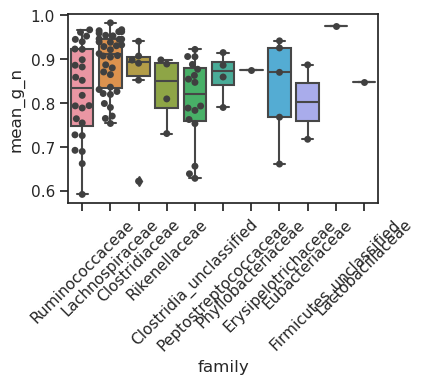

In [1496]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [4,2.5]
sns.boxplot(data=df_final[df_final.family.isin(enriched_sgbs.family.tolist())], x='family', y='mean_g_n')
sns.swarmplot(data=df_final[df_final.family.isin(enriched_sgbs.family.tolist())], x='family', y='mean_g_n', color=".25")
locs, labels = plt.pyplot.xticks()
plt.pyplot.setp(labels, rotation=45)
plt.pyplot.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/family_cluster_enr.svg')

''

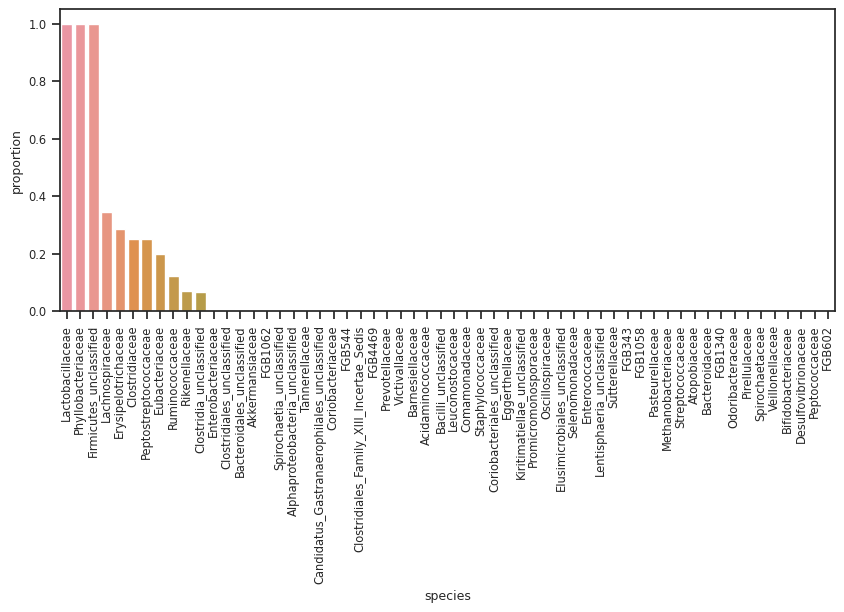

In [1081]:
sns.set(font_scale=0.75)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [10,4]
for_barplot = pd.DataFrame(family2number.sgb_number_enr  / family2number.sgb_number )
for_barplot.columns = ['proportion']
for_barplot['species'] = for_barplot.index
sns.barplot(data=for_barplot.sort_values('proportion', ascending=False), y='proportion', x='species')
locs, labels = plt.pyplot.xticks()
plt.pyplot.setp(labels, rotation=90)
;

## Distances and polymorphisms

In [2]:
distances = pd.read_table('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_distances_final.tsv', sep=',', index_col=[0])
distances.index = [x[3:] for x in distances.index]
distances

,NW_avg_dist,W_avg_dist,fold_change,NW_median_dist,W_median_dist,p_value,NW_p_value,W_p_value,FDR,NW_FDR,W_FDR
SGB12676,0.027909,0.032670,0.854280,0.027068,0.030250,9.738258e-02,9.028496e-01,9.738258e-02,1.083826e-01,1.000000e+00,2.861681e-01
SGB2241,0.019287,0.010714,1.800122,0.017987,0.010876,2.006475e-31,2.006475e-31,1.000000e+00,4.123737e-31,6.055578e-31,1.000000e+00
SGB9202,0.018870,0.021465,0.879096,0.018078,0.020596,3.681091e-15,1.000000e+00,3.681091e-15,6.228108e-15,1.000000e+00,1.787196e-14
SGB6846,0.011216,0.019417,0.577601,0.010441,0.019159,2.276024e-85,1.000000e+00,2.276024e-85,6.301389e-85,1.000000e+00,2.006495e-84
SGB8022,0.017582,0.012562,1.399574,0.015988,0.012562,2.702409e-01,2.702409e-01,7.300130e-01,2.811512e-01,4.504014e-01,1.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...
SGB15300,0.001309,0.000955,1.371139,0.001120,0.000949,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
SGB14546_group,0.000804,0.000630,1.277199,0.000769,0.000618,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
SGB4874,0.001486,0.000864,1.720523,0.001103,0.000865,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
SGB1814,0.001917,0.002520,0.760861,0.001886,0.002435,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00


In [3]:
polymorphisms = pd.read_table('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_poly_final.tsv', sep=',', index_col=[0])
polymorphisms.index = [x[3:] for x in polymorphisms.index]
polymorphisms

,NW_avg_poly,W_avg_poly,fold_change,NW_median_poly,W_median_poly,p_value,NW_p_value,W_p_value,FDR,NW_FDR,W_FDR
SGB4705,0.700959,0.538664,1.301292,0.665604,0.487353,8.878381e-07,8.878381e-07,0.999999,2.351754e-06,3.385492e-06,1.000000
SGB12676,0.335515,0.294565,1.139018,0.271987,0.256466,3.653964e-01,3.653964e-01,0.638142,3.925466e-01,6.708601e-01,1.000000
SGB17153_group,5.076164,1.926839,2.634451,5.286027,1.240239,2.954302e-05,2.954302e-05,0.999971,6.571428e-05,9.763265e-05,1.000000
SGB15238,0.956064,0.680033,1.405909,0.843723,0.545890,2.322448e-06,2.322448e-06,0.999998,5.882406e-06,8.308140e-06,1.000000
SGB9340,0.261173,0.332096,0.786438,0.261173,0.302150,3.316573e-01,6.696976e-01,0.331657,3.619027e-01,1.000000e+00,0.865301
...,...,...,...,...,...,...,...,...,...,...,...
SGB15107,1.258211,0.682226,1.844274,1.028206,0.620970,1.411309e-09,1.411309e-09,1.000000,4.708888e-09,6.443741e-09,1.000000
SGB4575,1.103422,0.752522,1.466299,1.044207,0.723719,2.397919e-31,2.397919e-31,1.000000,2.521448e-30,2.600243e-30,1.000000
SGB4829,0.757261,0.919624,0.823446,0.743283,0.844763,5.009744e-03,9.949964e-01,0.005010,8.010973e-03,1.000000e+00,0.019754
SGB1949,0.377786,0.499470,0.756374,0.317893,0.444210,3.694908e-06,9.999963e-01,0.000004,9.223979e-06,1.000000e+00,0.000031


In [1215]:
df_score

,mean_g_n,median,mean,k,yes,no,family,min_size,labels,min_score,tax
SGB15238,0.591751,0.690476,0.727088,10,12,297,Ruminococcaceae,12,1,0.500000,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...
SGB4571,0.826420,0.826420,0.826420,2,11,320,Lachnospiraceae,11,1,0.743750,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...
SGB2071,0.750075,0.750075,0.750075,2,283,824,Bacteroidales_unclassified,283,1,0.705097,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...
SGB6178,0.852273,0.852273,0.852273,2,38,308,Clostridiaceae,38,1,0.704545,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...
SGB2238,0.809503,0.906040,0.870489,3,162,129,Rikenellaceae,129,2,0.705426,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...
...,...,...,...,...,...,...,...,...,...,...,...
SGB15019,0.922650,0.922222,0.885762,3,90,169,Ruminococcaceae,90,1,0.800000,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...
SGB5090_group,0.737105,0.737105,0.737105,2,202,2685,Clostridiales_unclassified,202,1,0.529703,k__Bacteria|p__Firmicutes|c__Clostridia|o__Clo...
SGB7061,0.847074,0.895455,0.897124,3,226,343,Lactobacillaceae,226,2,0.795918,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactob...
SGB14773_group,0.828534,0.828534,0.828534,2,231,382,Eggerthellaceae,231,1,0.657068,k__Bacteria|p__Actinobacteria|c__Coriobacterii...


In [8]:
df_final = distances.join(polymorphisms.loc[distances.index],how='left', lsuffix='_left', rsuffix='_right')
# df_final = df_score.join(df_final.loc[df_score.index])
df_final['sig_left'] = df_final['FDR_left'] < 0.05
df_final['sig_right'] = df_final['FDR_right'] < 0.05
df_final['dist_r'] = df_final['W_avg_dist'] > df_final['NW_avg_dist']
df_final['dist_r'] = df_final['dist_r'].astype(int)
df_final.loc[df_final.sig_left == False, 'dist_r']  = 2
df_final['poly_r'] = df_final['W_avg_poly'] > df_final['NW_avg_poly']
df_final['poly_r'] = df_final['poly_r'].astype(int)
df_final.loc[df_final.sig_right == False, 'poly_r']  = 2
# df_final['W_avg_dist'] = pd.DataFrame(df_final['W_avg_dist']).applymap(math.log10)
# df_final['NW_avg_dist'] = pd.DataFrame(df_final['NW_avg_dist']).applymap(math.log10)
# df_final['W_avg_poly'] = pd.DataFrame(df_final['W_avg_poly']).applymap(math.log10)
# df_final['NW_avg_poly'] = pd.DataFrame(df_final['NW_avg_poly']).applymap(math.log10)
# df_final = df_final[(df_final.min_score > 0.75) & (df_final.no > 200) & (df_final.yes > 20)]
# df_final = df_final[(df_final.no > 200) & (df_final.yes > 20)]
df_final

AttributeError: 'DataFrame' object has no attribute 'no'

,NW_avg_dist,W_avg_dist,fold_change_left,NW_median_dist,W_median_dist,p_value_left,NW_p_value_left,W_p_value_left,FDR_left,NW_FDR_left,...,W_median_poly,p_value_right,NW_p_value_right,W_p_value_right,FDR_right,NW_FDR_right,W_FDR_right,sig_left,sig_right,dist_r
SGB12676,0.027909,0.032670,0.854280,0.027068,0.030250,0.097383,0.902850,0.097383,0.108383,1.000000,...,0.256466,3.653964e-01,3.653964e-01,6.381423e-01,3.925466e-01,6.708601e-01,1.000000e+00,False,False,1
SGB8022,0.017582,0.012562,1.399574,0.015988,0.012562,0.270241,0.270241,0.730013,0.281151,0.450401,...,0.650613,4.470775e-01,5.553130e-01,4.470775e-01,4.522912e-01,9.354058e-01,1.000000e+00,False,False,0
SGB17153_group,0.017687,0.014218,1.243989,0.017564,0.014231,0.092616,0.092616,0.907431,0.103768,0.165917,...,1.240239,2.954302e-05,2.954302e-05,9.999713e-01,6.571428e-05,9.763265e-05,1.000000e+00,False,True,0
SGB27424,0.021434,0.018263,1.173646,0.018598,0.017663,0.089894,0.089894,0.910284,0.101056,0.161906,...,0.367075,1.651695e-02,1.651695e-02,9.837497e-01,2.449308e-02,4.183490e-02,1.000000e+00,False,True,0
SGB14822,0.017252,0.017228,1.001405,0.017027,0.019352,0.130386,0.869626,0.130386,0.144634,1.000000,...,0.405923,1.556997e-04,1.556997e-04,9.998459e-01,3.122994e-04,4.867369e-04,1.000000e+00,False,True,0
SGB1857,0.006461,0.007249,0.891299,0.006461,0.007282,0.457120,0.542920,0.457120,0.459866,0.861981,...,0.312320,1.271518e-03,9.987361e-01,1.271518e-03,2.251106e-03,1.000000e+00,5.962390e-03,False,True,1
SGB14114,0.018087,0.016129,1.121401,0.019495,0.017180,0.225003,0.225003,0.775011,0.237031,0.380687,...,0.376565,2.877314e-01,7.130739e-01,2.877314e-01,3.200090e-01,1.000000e+00,7.800219e-01,False,False,0
SGB15180,0.007668,0.009625,0.796672,0.007823,0.007817,0.172831,0.827177,0.172831,0.185842,1.000000,...,0.481664,3.280927e-01,6.722808e-01,3.280927e-01,3.591425e-01,1.000000e+00,8.624862e-01,False,False,1
SGB72475_group,0.014732,0.007860,1.874166,0.014565,0.007860,0.046354,0.046354,0.953678,0.054106,0.085793,...,0.221720,1.009133e-01,1.009133e-01,9.006278e-01,1.292137e-01,2.188557e-01,1.000000e+00,False,False,0
SGB4051_group,0.101650,0.082124,1.237765,0.116656,0.080477,0.178766,0.178766,0.821442,0.191331,0.307110,...,0.140312,1.535351e-01,1.535351e-01,8.491075e-01,1.889244e-01,3.152466e-01,1.000000e+00,False,False,0


(0.3673241972875372, 0.014173676419012586)


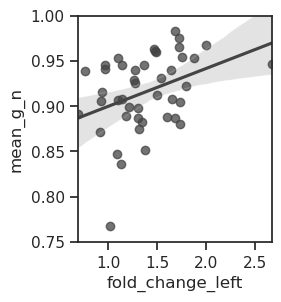

In [1536]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [2.5,3]
g = sns.regplot(data=df_final, x='fold_change_left', scatter_kws={'alpha':0.75}, y='mean_g_n', color='#444444')
print(stats.pearsonr(df_final['fold_change_left'], df_final['mean_g_n']))
g.set(ylim=(0.75, 1))
plt.pyplot.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/purity_distance.svg')

(-0.40645689658948114, 0.006184894493951005)


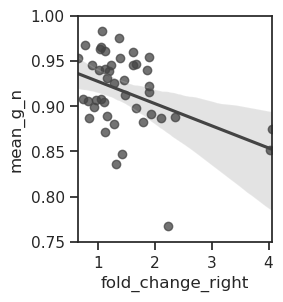

In [1538]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [2.5,3]
g = sns.regplot(data=df_final, x='fold_change_right', scatter_kws={'alpha':0.75}, y='mean_g_n', color='#444444')
g.set(ylim=(0.75, 1))
print(stats.pearsonr(df_final['fold_change_right'], df_final['mean_g_n']))
plt.pyplot.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/purity_poly.svg')

In [48]:
df_final.to_csv('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/phylo_strainphlan.tsv', sep='\t')

WilcoxonResult(statistic=16713.0, pvalue=1.1832695742605244e-10)

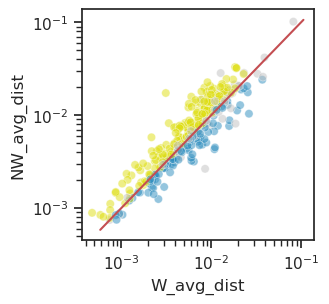

In [24]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [3,3]
g = sns.scatterplot(data=df_final, x='W_avg_dist', y='NW_avg_dist', hue='dist_r',  alpha=0.5, palette=['#dede0e','#2b8cbe','#c0c0c0'], legend=False)
g.set_yscale('log')
g.set_xscale('log')
x0, x1 = g.get_xlim()
y0, y1 = g.get_ylim()
lims = [max(x0, y0), min(x1, y1)]
g.plot(lims, lims, '-r')
stats.pearsonr(df_final['W_avg_dist'], df_final['NW_avg_dist'])
stats.wilcoxon(df_final['W_avg_dist'], df_final['NW_avg_dist'])
# plt.pyplot.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/dist_comp.svg')

In [22]:
pd.DataFrame(df_final['W_avg_dist'] < df_final['NW_avg_dist']).astype(int).sum() / pd.DataFrame(df_final['W_avg_dist'] < df_final['NW_avg_dist']).astype(int).count()

0    335
dtype: int64

WilcoxonResult(statistic=13831.0, pvalue=7.26014390359276e-16)

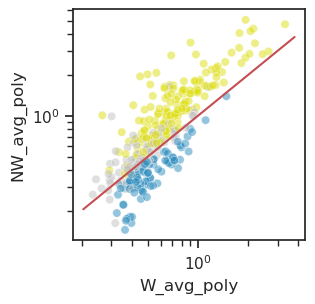

In [25]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [3,3]
g = sns.scatterplot(data=df_final, x='W_avg_poly', y='NW_avg_poly', hue='poly_r',  palette=['#dede0e','#2b8cbe','#c0c0c0'], alpha=0.5, legend=False)
g.set_yscale('log')
g.set_xscale('log')
x0, x1 = g.get_xlim()
y0, y1 = g.get_ylim()
lims = [max(x0, y0), min(x1, y1)]
g.plot(lims, lims, '-r')
stats.pearsonr(df_final['W_avg_poly'], df_final['NW_avg_poly'])
stats.wilcoxon(df_final['W_avg_poly'], df_final['NW_avg_poly'])
# plt.pyplot.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/poly_comp.svg')

In [19]:
pd.DataFrame(df_final['W_avg_poly'] < df_final['NW_avg_poly']).astype(int).sum() / pd.DataFrame(df_final['W_avg_poly'] < df_final['NW_avg_poly']).astype(int).count()

0    0.647761
dtype: float64

(-0.28056618735619043, 1.7771818651462349e-07)

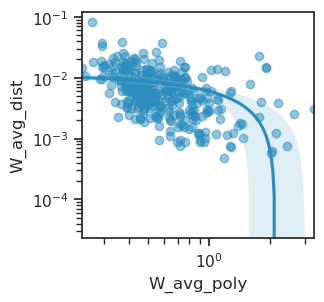

In [1464]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [3,3]
g = sns.regplot(data=df_final, x='W_avg_poly', y='W_avg_dist', scatter_kws={'alpha':0.5}, color="#2b8cbe")
g.set_xscale('log')
g.set_yscale('log')
stats.pearsonr(df_final['W_avg_poly'], df_final['W_avg_dist'])
# plt.pyplot.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/w_comp.svg')

PearsonRResult(statistic=-0.2805661873561904, pvalue=1.7771818651464755e-07)

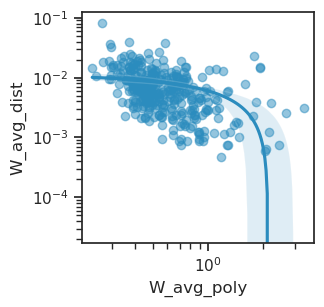

In [26]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [3,3]
g = sns.regplot(data=df_final, x='W_avg_poly', y='W_avg_dist', scatter_kws={'alpha':0.5}, color="#2b8cbe")
g.set_xscale('log')
g.set_yscale('log')
stats.pearsonr(df_final['W_avg_poly'], df_final['W_avg_dist'])

(-0.14199917227795322, 0.009254750883051764)

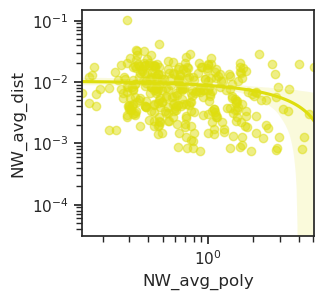

In [1465]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [3,3]
g = sns.regplot(data=df_final, x='NW_avg_poly', y='NW_avg_dist', scatter_kws={'alpha':0.5}, color="#dede0e")
g.set_xscale('log')
g.set_yscale('log')
stats.pearsonr(df_final['NW_avg_poly'], df_final['NW_avg_dist'])
# plt.pyplot.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/nw_comp.svg')